In [1]:
#!/usr/bin/env python3
r"""
Fast LmrR EVB/QM preparation workflow.

This is meant to replace the slow "run everything in VeloxChem for all steps"
workflow.  By default it only prepares files; it does not launch expensive jobs.

Main ideas
----------
1. Preserve your PDB atom order and atom numbering by converting the existing
   capped PDB files to XYZ and writing a serial-to-XYZ-index map.
2. Prepare xTB jobs for fast pre-optimization of RS/TS/PS structures.
3. Optionally run xTB one step at a time if `xtb` is installed.
4. Export ORCA/Gaussian input files for final QM optimization/frequency jobs.
5. Optionally run the VeloxChem SMILES TS guesser in FAST mode only
   (no relaxed QM scan, no py3Dmol viewer).

Important
---------
- PDB serial numbers are not always the same as XYZ line indices, because the
  capped step-1 PDBs skip some serials. The generated `*_pdb_to_xyz_map.csv`
  files are therefore essential.
- The final barriers still require optimized RS/TS/PS energies and frequencies.
  This script gives fast starting points and final-QM input files.
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import os
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable


BASE_DIR = Path(r"D:\PhD_Thesis\LmrR_EVB")
CHARGES_DIR = BASE_DIR / "charges"
# Keep this workflow outside the `results` folder by default.
# The user wants code and generated fast-job files directly under `charges`.
RESULTS_DIR = CHARGES_DIR / "fast_lmrr_evb_qm"

HARTREE_TO_KJMOL = 2625.499638


@dataclass(frozen=True)
class PDBAtom:
    serial: int
    name: str
    resname: str
    chain: str
    resid: str
    x: float
    y: float
    z: float
    element: str

    @property
    def res_atom(self) -> str:
        return f"{self.resname}.{self.name}"

    @property
    def pdb_id(self) -> str:
        return f"{self.resid}.{self.name}"


@dataclass(frozen=True)
class BondChange:
    kind: str
    serial_i: int
    serial_j: int
    note: str


@dataclass(frozen=True)
class StructureSet:
    label: str
    rs_pdb: str
    ts_pdb: str
    ps_pdb: str
    charge: int
    multiplicity: int
    bond_changes: tuple[BondChange, ...]
    comment: str


STRUCTURE_SETS: dict[str, StructureSet] = {
    "RS1_1_to_TS1_2": StructureSet(
        label="RS1_1_to_TS1_2",
        rs_pdb="step_1_1_RS.pdb",
        ts_pdb="step_1_1_TS.pdb",
        ps_pdb="step_1_1_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("formed", 1, 10, "PAF.N2 attacks ENL.C10; N-C bond formation"),
            BondChange("weakened", 10, 16, "ENL.C10=O1 carbonyl weakens"),
        ),
        comment="Step 1.1 addition. Use TS as a starting TS guess; PS is the tetrahedral state.",
    ),
    "TS1_2_to_PS1_2b": StructureSet(
        label="TS1_2_to_PS1_2b",
        rs_pdb="step_1_2_RS.pdb",
        ts_pdb="step_1_2_TS.pdb",
        ps_pdb="step_1_2_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 1, 29, "PAF N-H breaks"),
            BondChange("formed", 27, 29, "W1 accepts H29"),
            BondChange("broken", 60, 61, "W2 O-H breaks"),
            BondChange("formed", 16, 61, "ENL.O1 accepts H61"),
        ),
        comment="Two-water proton redistribution.",
    ),
    "RS1_2b_to_PS1_3": StructureSet(
        label="RS1_2b_to_PS1_3",
        rs_pdb="step_1_3_RS.pdb",
        ts_pdb="step_1_3_TS.pdb",
        ps_pdb="step_1_3_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 27, 29, "W1 hydronium O-H breaks"),
            BondChange("formed", 16, 29, "carbinolamine O accepts H29"),
            BondChange("broken", 10, 16, "C-O leaving-water bond breaks"),
            BondChange("double-bond formed", 1, 10, "iminium N=C forms"),
        ),
        comment="Dehydration to iminium.",
    ),
    "RS2_1_to_TS2_1a": StructureSet(
        label="RS2_1_to_TS2_1a",
        rs_pdb="step_2_1_RS.pdb",
        ts_pdb="step_2_1_TS.pdb",
        ps_pdb="step_2_1_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("formed", 12, 20, "new C-C sigma bond ENL.C12--IND.C3"),
            BondChange("weakened", 1, 10, "iminium N=C weakens"),
            BondChange("strengthened", 10, 11, "C10-C11 bond strengthens"),
        ),
        comment="Friedel-Crafts C-C bond formation.",
    ),
    "TS2_1a_to_PS2_2": StructureSet(
        label="TS2_1a_to_PS2_2",
        # For the combined 2.2 tautomerization, use 2.2a RS as the early state,
        # 2.2b TS as the final-proton-transfer TS guess, and 2.2b PS as PS2.2.
        rs_pdb="step_2_2a_RS.pdb",
        ts_pdb="step_2_2b_TS.pdb",
        ps_pdb="step_2_2b_PS.pdb",
        charge=0,
        multiplicity=1,
        bond_changes=(
            BondChange("broken", 20, 50, "IND.C3-H50 breaks"),
            BondChange("formed", 60, 50, "W2 accepts H50"),
            BondChange("broken", 27, 58, "W1 O-H58 breaks"),
            BondChange("formed", 11, 58, "ENL.C11 accepts H58"),
            BondChange("double-bond formed", 1, 10, "N=C/enamine bond order changes"),
        ),
        comment="Combined 2.2 tautomerization. If you want separate 2.2a/2.2b, split this entry.",
    ),
}


STATE_SMILES = {
    "RS1.1": "CC(=O)NC(Cc1ccc(N)cc1)C(=O)NC.CCC/C=C/C=O",
    "TS1.2": "CC(=O)NC(Cc1ccc([NH2+][CH]([O-])/C=C/CCC)cc1)C(=O)NC",
    "PS1.2b": "CC(=O)NC(Cc1ccc(N[CH](O)/C=C/CCC)cc1)C(=O)NC",
    "RS1.2b": "CC(=O)NC(Cc1ccc(N[CH](O)/C=C/CCC)cc1)C(=O)NC",
    "PS1.3": "CC(=O)NC(Cc1ccc([NH+]=[CH]/C=C/CCC)cc1)C(=O)NC.O",
    "RS2.1": "CC(=O)NC(Cc1ccc([NH+]=[CH]/C=C/CCC)cc1)C(=O)NC.c1ccc2[nH]ccc2c1",
    "TS2.1a": "CC(=O)NC(Cc1ccc(N/C=C/C(CCC)C2C=[NH+]c3ccccc23)cc1)C(=O)NC",
    "PS2.2": "CC(=O)NC(Cc1ccc([NH+]=[CH]CC(CCC)c2c[nH]c3ccccc23)cc1)C(=O)NC",
    "H3O+": "[OH3+]",
    "H2O": "O",
}


SMILES_TRANSITIONS = {
    "RS1_1_to_TS1_2": (["RS1.1"], ["TS1.2"]),
    "TS1_2_to_PS1_2b": (["TS1.2"], ["PS1.2b"]),
    "RS1_2b_to_PS1_3": (["RS1.2b", "H3O+"], ["PS1.3", "H2O"]),
    "RS2_1_to_TS2_1a": (["RS2.1"], ["TS2.1a"]),
    "TS2_1a_to_PS2_2": (["TS2.1a"], ["PS2.2"]),
}


def selected_steps(step_args: Iterable[str] | None) -> list[str]:
    if not step_args:
        return list(STRUCTURE_SETS)
    out: list[str] = []
    for raw in step_args:
        for item in raw.split(","):
            item = item.strip()
            if not item:
                continue
            if item not in STRUCTURE_SETS:
                raise SystemExit(f"Unknown step {item!r}. Available: {', '.join(STRUCTURE_SETS)}")
            out.append(item)
    return out


def infer_element(atom_name: str, explicit: str = "") -> str:
    if explicit:
        return explicit.strip().capitalize()
    letters = "".join(ch for ch in atom_name if ch.isalpha())
    if not letters:
        return "X"
    two = letters[:2].capitalize()
    if two in {"Cl", "Br"}:
        return two
    return letters[0].upper()


def parse_pdb(path: Path) -> list[PDBAtom]:
    atoms: list[PDBAtom] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.startswith(("ATOM  ", "HETATM")):
            continue
        atoms.append(
            PDBAtom(
                serial=int(line[6:11]),
                name=line[12:16].strip(),
                resname=line[17:20].strip(),
                chain=line[21:22].strip(),
                resid=line[22:26].strip(),
                x=float(line[30:38]),
                y=float(line[38:46]),
                z=float(line[46:54]),
                element=infer_element(line[12:16].strip(), line[76:78].strip()),
            )
        )
    if not atoms:
        raise ValueError(f"No atoms found in {path}")
    return atoms


def write_xyz_from_pdb(pdb_path: Path, xyz_path: Path, map_csv_path: Path) -> dict[int, int]:
    atoms = parse_pdb(pdb_path)
    xyz_path.parent.mkdir(parents=True, exist_ok=True)
    serial_to_xyz_index: dict[int, int] = {}
    with xyz_path.open("w", encoding="utf-8") as f:
        f.write(f"{len(atoms)}\n")
        f.write(f"from {pdb_path.name}; PDB serial map in {map_csv_path.name}\n")
        for xyz_index, atom in enumerate(atoms, start=1):
            serial_to_xyz_index[atom.serial] = xyz_index
            f.write(f"{atom.element:<2s} {atom.x:14.8f} {atom.y:14.8f} {atom.z:14.8f}\n")

    with map_csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "xyz_index",
                "pdb_serial",
                "pdb_id",
                "res_atom",
                "chain",
                "resid",
                "resname",
                "atom_name",
                "element",
            ],
        )
        writer.writeheader()
        for xyz_index, atom in enumerate(atoms, start=1):
            writer.writerow(
                {
                    "xyz_index": xyz_index,
                    "pdb_serial": atom.serial,
                    "pdb_id": atom.pdb_id,
                    "res_atom": atom.res_atom,
                    "chain": atom.chain,
                    "resid": atom.resid,
                    "resname": atom.resname,
                    "atom_name": atom.name,
                    "element": atom.element,
                }
            )
    return serial_to_xyz_index


def read_xyz(path: Path) -> tuple[list[str], list[tuple[float, float, float]], str]:
    lines = path.read_text(encoding="utf-8").splitlines()
    n = int(lines[0].strip())
    comment = lines[1] if len(lines) > 1 else ""
    labels: list[str] = []
    coords: list[tuple[float, float, float]] = []
    for line in lines[2 : 2 + n]:
        parts = line.split()
        labels.append(parts[0])
        coords.append((float(parts[1]), float(parts[2]), float(parts[3])))
    return labels, coords, comment


def distance_from_xyz(xyz_path: Path, idx_i: int, idx_j: int) -> float:
    _, coords, _ = read_xyz(xyz_path)
    xi, yi, zi = coords[idx_i - 1]
    xj, yj, zj = coords[idx_j - 1]
    return math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2 + (zi - zj) ** 2)


def write_xtb_constraint(path: Path, constraints: list[tuple[int, int, float]]) -> None:
    lines = ["$constrain"]
    for i, j, dist in constraints:
        lines.append(f"  distance: {i}, {j}, {dist:.4f}")
    lines.append("$end")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def write_xtb_runner(
    run_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    constraint_file: Path | None,
    output_prefix: str,
) -> None:
    uhf = max(0, multiplicity - 1)
    cmd = [
        "xtb",
        xyz_path.name,
        "--gfn",
        "2",
        "--opt",
        "tight",
        "--chrg",
        str(charge),
        "--uhf",
        str(uhf),
    ]
    if constraint_file is not None:
        cmd.extend(["--input", constraint_file.name])
    command = " ".join(cmd)
    run_path.write_text(
        "\n".join(
            [
                "$ErrorActionPreference = 'Stop'",
                f"Set-Location -LiteralPath '{run_path.parent}'",
                command + f" *> {output_prefix}.xtb.log",
                "if (Test-Path xtbopt.xyz) {",
                f"    Copy-Item -LiteralPath xtbopt.xyz -Destination {output_prefix}_xtbopt.xyz -Force",
                "}",
                "if (Test-Path xtbopt.log) {",
                f"    Copy-Item -LiteralPath xtbopt.log -Destination {output_prefix}_xtbopt.log -Force",
                "}",
                "if (Test-Path xtbrestart) {",
                f"    Copy-Item -LiteralPath xtbrestart -Destination {output_prefix}.xtbrestart -Force",
                "}",
                "",
            ]
        ),
        encoding="utf-8",
    )


def write_orca_input(
    inp_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    job_type: str,
    nprocs: int = 8,
    memory_mb: int = 3000,
) -> None:
    labels, coords, _ = read_xyz(xyz_path)
    if job_type == "ts":
        route = "! B3LYP D3BJ def2-SVP OptTS NumFreq TightSCF"
    elif job_type == "freq":
        route = "! B3LYP D3BJ def2-SVP Freq TightSCF"
    else:
        route = "! B3LYP D3BJ def2-SVP Opt Freq TightSCF"
    lines = [
        route,
        f"%pal nprocs {nprocs} end",
        f"%maxcore {memory_mb}",
        "",
        f"* xyz {charge} {multiplicity}",
    ]
    for label, (x, y, z) in zip(labels, coords):
        lines.append(f"  {label:<2s} {x:14.8f} {y:14.8f} {z:14.8f}")
    lines.append("*")
    lines.append("")
    inp_path.write_text("\n".join(lines), encoding="utf-8")


def write_gaussian_input(
    gjf_path: Path,
    xyz_path: Path,
    charge: int,
    multiplicity: int,
    job_type: str,
    nprocs: int = 8,
    memory_gb: int = 16,
) -> None:
    labels, coords, _ = read_xyz(xyz_path)
    opt_keyword = "Opt=(TS,CalcFC,NoEigenTest) Freq" if job_type == "ts" else "Opt Freq"
    lines = [
        f"%nprocshared={nprocs}",
        f"%mem={memory_gb}GB",
        f"#p B3LYP/def2SVP EmpiricalDispersion=GD3BJ {opt_keyword}",
        "",
        f"{xyz_path.stem} {job_type}",
        "",
        f"{charge} {multiplicity}",
    ]
    for label, (x, y, z) in zip(labels, coords):
        lines.append(f"{label:<2s} {x:14.8f} {y:14.8f} {z:14.8f}")
    lines.extend(["", ""])
    gjf_path.write_text("\n".join(lines), encoding="utf-8")


def prepare_pdb_preserving_jobs(steps: list[str], overwrite: bool = True) -> None:
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    prep_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for step in steps:
        cfg = STRUCTURE_SETS[step]
        step_dir = prep_dir / step
        step_dir.mkdir(parents=True, exist_ok=True)
        serial_maps: dict[str, dict[int, int]] = {}

        for role, pdb_name, qm_job_type in [
            ("RS", cfg.rs_pdb, "min"),
            ("TS", cfg.ts_pdb, "ts"),
            ("PS", cfg.ps_pdb, "min"),
        ]:
            pdb_path = CHARGES_DIR / pdb_name
            if not pdb_path.exists():
                raise FileNotFoundError(pdb_path)
            xyz_path = step_dir / f"{step}_{role}.xyz"
            map_csv = step_dir / f"{step}_{role}_pdb_to_xyz_map.csv"
            if overwrite or not xyz_path.exists():
                serial_maps[role] = write_xyz_from_pdb(pdb_path, xyz_path, map_csv)
            else:
                # Read existing map.
                serial_maps[role] = {}
                with map_csv.open(newline="", encoding="utf-8") as f:
                    for row in csv.DictReader(f):
                        serial_maps[role][int(row["pdb_serial"])] = int(row["xyz_index"])

            write_orca_input(step_dir / f"{step}_{role}.inp", xyz_path, cfg.charge, cfg.multiplicity, qm_job_type)
            write_gaussian_input(step_dir / f"{step}_{role}.gjf", xyz_path, cfg.charge, cfg.multiplicity, qm_job_type)
            write_xtb_runner(
                step_dir / f"run_xtb_{role}.ps1",
                xyz_path,
                cfg.charge,
                cfg.multiplicity,
                constraint_file=None,
                output_prefix=f"{step}_{role}",
            )

            summary_rows.append(
                {
                    "step": step,
                    "role": role,
                    "pdb": str(pdb_path),
                    "xyz": str(xyz_path),
                    "map_csv": str(map_csv),
                    "orca_input": str(step_dir / f"{step}_{role}.inp"),
                    "gaussian_input": str(step_dir / f"{step}_{role}.gjf"),
                    "xtb_runner": str(step_dir / f"run_xtb_{role}.ps1"),
                    "charge": cfg.charge,
                    "multiplicity": cfg.multiplicity,
                    "comment": cfg.comment,
                }
            )

        # Write constrained xTB TS preoptimization for the TS structure.
        ts_xyz = step_dir / f"{step}_TS.xyz"
        ts_map = serial_maps["TS"]
        constraints: list[tuple[int, int, float]] = []
        for change in cfg.bond_changes:
            if change.kind in {"formed", "broken", "double-bond formed"}:
                if change.serial_i in ts_map and change.serial_j in ts_map:
                    i_xyz = ts_map[change.serial_i]
                    j_xyz = ts_map[change.serial_j]
                    dist = distance_from_xyz(ts_xyz, i_xyz, j_xyz)
                    constraints.append((i_xyz, j_xyz, dist))
        if constraints:
            constraint_file = step_dir / f"{step}_TS_xtb_constraints.inp"
            write_xtb_constraint(constraint_file, constraints)
            write_xtb_runner(
                step_dir / "run_xtb_TS_constrained.ps1",
                ts_xyz,
                cfg.charge,
                cfg.multiplicity,
                constraint_file=constraint_file,
                output_prefix=f"{step}_TS_constrained",
            )

        # Human-readable bond map for this step.
        atoms = parse_pdb(CHARGES_DIR / cfg.ts_pdb)
        by_serial = {a.serial: a for a in atoms}
        bond_lines = [
            f"# {step}",
            f"# {cfg.comment}",
            "# PDB serial -> atom identity; XYZ index is taken from TS map",
        ]
        for change in cfg.bond_changes:
            ai = by_serial[change.serial_i]
            aj = by_serial[change.serial_j]
            bond_lines.append(
                f"{change.kind:18s} PDB {change.serial_i:>3}-{change.serial_j:<3} "
                f"XYZ {ts_map[change.serial_i]:>3}-{ts_map[change.serial_j]:<3} "
                f"{ai.res_atom} -- {aj.res_atom} ; {change.note}"
            )
        (step_dir / f"{step}_bond_map.txt").write_text("\n".join(bond_lines) + "\n", encoding="utf-8")

    summary_csv = prep_dir / "prepared_fast_jobs_summary.csv"
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "step",
                "role",
                "pdb",
                "xyz",
                "map_csv",
                "orca_input",
                "gaussian_input",
                "xtb_runner",
                "charge",
                "multiplicity",
                "comment",
            ],
        )
        writer.writeheader()
        writer.writerows(summary_rows)
    print(f"Prepared PDB-preserving xTB/QM inputs in: {prep_dir}")
    print(f"Summary: {summary_csv}")


def run_xtb_jobs(steps: list[str], roles: list[str]) -> None:
    xtb = shutil.which("xtb")
    if not xtb:
        raise SystemExit(
            "Could not find xtb on PATH. Install xTB or use the prepared run_xtb_*.ps1 files on a machine with xTB."
        )
    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    for step in steps:
        step_dir = prep_dir / step
        for role in roles:
            runner = step_dir / f"run_xtb_{role}.ps1"
            if role == "TS_constrained":
                runner = step_dir / "run_xtb_TS_constrained.ps1"
            if not runner.exists():
                print(f"Skipping missing runner: {runner}")
                continue
            print(f"Running {runner}")
            subprocess.run(["powershell", "-NoProfile", "-ExecutionPolicy", "Bypass", "-File", str(runner)], check=True)


def _safe_float(value):
    try:
        return float(value)
    except Exception:
        return None


def _scan_items(result):
    scan = result.get("scan", {}) if isinstance(result, dict) else {}
    if not isinstance(scan, dict):
        return []
    items = []
    for lam, records in scan.items():
        if isinstance(records, dict):
            records = [records]
        for idx, rec in enumerate(records or []):
            if isinstance(rec, dict):
                items.append((lam, idx, rec))
    return items


def write_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def write_csv(path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def run_veloxchem_fast(steps: list[str]) -> None:
    try:
        import veloxchem as vlx
    except Exception as exc:
        raise SystemExit(f"VeloxChem is not importable in this Python environment: {exc}") from exc

    out_dir = RESULTS_DIR / "veloxchem_fast_smiles_guesses"
    out_dir.mkdir(parents=True, exist_ok=True)
    summary_rows = []

    for step in steps:
        reactant_labels, product_labels = SMILES_TRANSITIONS[step]
        reactants = [vlx.Molecule.read_smiles(STATE_SMILES[label]) for label in reactant_labels]
        products = [vlx.Molecule.read_smiles(STATE_SMILES[label]) for label in product_labels]

        guesser = vlx.TransitionStateGuesser()
        # The key speed choices: no QM rescoring/relaxed QM scan and no viewer.
        for attr, value in [
            ("scf_scan", False),
            ("do_qm_scan", False),
            ("qm_scan", False),
            ("optimize_ts", False),
            ("do_ts_optimization", False),
            ("mute_ff_build", True),
        ]:
            if hasattr(guesser, attr):
                setattr(guesser, attr, value)

        print(f"\n=== VeloxChem FAST guess: {step} ===")
        result = guesser.find_transition_state(reactants, products)
        step_dir = out_dir / step
        step_dir.mkdir(parents=True, exist_ok=True)

        for key in ["max_mm_xyz", "max_qm_xyz"]:
            if isinstance(result, dict) and key in result:
                write_text(step_dir / f"{step}_{key}.xyz", result[key])

        scan_rows = []
        for lam, idx, rec in _scan_items(result):
            xyz = rec.get("qm_xyz") or rec.get("mm_xyz") or rec.get("xyz")
            if xyz:
                write_text(step_dir / f"lambda_{float(lam):.2f}_conf_{idx}.xyz", xyz)
            scan_rows.append(
                {
                    "step": step,
                    "lambda": float(lam),
                    "conformer_index": idx,
                    "mm_energy": rec.get("mm_energy", ""),
                    "qm_energy": rec.get("qm_energy", ""),
                    "has_xyz": bool(xyz),
                }
            )
        if scan_rows:
            write_csv(
                step_dir / f"{step}_veloxchem_fast_scan.csv",
                scan_rows,
                ["step", "lambda", "conformer_index", "mm_energy", "qm_energy", "has_xyz"],
            )

        summary_rows.append(
            {
                "step": step,
                "reactants": " + ".join(reactant_labels),
                "products": " + ".join(product_labels),
                "result_keys": ", ".join(result.keys()) if isinstance(result, dict) else "",
                "max_mm_lambda": result.get("max_mm_lambda", "") if isinstance(result, dict) else "",
                "max_qm_lambda": result.get("max_qm_lambda", "") if isinstance(result, dict) else "",
                "scan_points": len(scan_rows),
                "folder": str(step_dir),
            }
        )

    write_csv(
        out_dir / "veloxchem_fast_summary.csv",
        summary_rows,
        ["step", "reactants", "products", "result_keys", "max_mm_lambda", "max_qm_lambda", "scan_points", "folder"],
    )
    print(f"\nVeloxChem fast outputs: {out_dir}")


def write_readme() -> None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    readme = RESULTS_DIR / "README_fast_workflow.md"
    readme.write_text(
        """# Fast LmrR EVB/QM workflow

This folder is generated by `fast_lmrr_evb_qm_workflow.py`.

Recommended fast route:

1. Prepare PDB-preserving XYZ, xTB runners, and final-QM input files:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --prepare
   ```

2. Run xTB only for one step/role at a time, for example:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --run-xtb --steps RS2_1_to_TS2_1a --roles RS,TS,PS
   ```

   Or run the generated `run_xtb_*.ps1` files manually inside each step folder.

3. Use the generated ORCA `.inp` or Gaussian `.gjf` files for final B3LYP-D/def2-SVP
   optimization/frequency calculations.

4. Use VeloxChem only for quick SMILES TS guesses:

   ```powershell
   python fast_lmrr_evb_qm_workflow.py --veloxchem-fast --steps RS2_1_to_TS2_1a
   ```

Do not run all relaxed QM scans for all five steps in one notebook. That is the slow
path that can consume days without useful intermediate stopping points.
""",
        encoding="utf-8",
    )


def main() -> None:
    parser = argparse.ArgumentParser(description="Fast LmrR EVB/QM preparation workflow.")
    parser.add_argument("--steps", nargs="*", help="Step labels, comma-separated or space-separated.")
    parser.add_argument("--prepare", action="store_true", help="Prepare PDB-preserving XYZ/xTB/QM input files.")
    parser.add_argument("--run-xtb", action="store_true", help="Run prepared xTB jobs. Requires xtb on PATH.")
    parser.add_argument(
        "--roles",
        default="RS,TS,PS",
        help="Roles for --run-xtb: RS,TS,PS,TS_constrained. Default: RS,TS,PS.",
    )
    parser.add_argument("--veloxchem-fast", action="store_true", help="Run fast VeloxChem SMILES TS guesses only.")
    parser.add_argument("--list-steps", action="store_true", help="Print available step labels and exit.")
    args = parser.parse_args()

    if args.list_steps:
        print("\n".join(STRUCTURE_SETS))
        return

    steps = selected_steps(args.steps)
    write_readme()

    if not args.prepare and not args.run_xtb and not args.veloxchem_fast:
        print("No action requested. Preparing files by default.")
        args.prepare = True

    if args.prepare:
        prepare_pdb_preserving_jobs(steps)
    if args.run_xtb:
        roles = [x.strip() for x in args.roles.split(",") if x.strip()]
        run_xtb_jobs(steps, roles)
    if args.veloxchem_fast:
        run_veloxchem_fast(steps)


In [2]:
# ============================================================
# WINDOWS-SAFE xTB SUBPROCESS HELPERS
# ============================================================

def run_binary_command(cmd, cwd):
    """
    Capture xTB stdout/stderr as raw bytes first.
    Decode only afterwards with UTF-8/errors='replace'.

    This prevents UnicodeDecodeError from Windows cp1252.
    """
    result = subprocess.run(
        cmd,
        cwd=str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        check=False,
    )

    stdout = result.stdout.decode("utf-8", errors="replace")
    stderr = result.stderr.decode("utf-8", errors="replace")

    return result.returncode, stdout, stderr


In [3]:
# ============================================================
# xTB OPTIMIZATION — WINDOWS-SAFE
# ============================================================

def run_xtb_opt(step, role, overwrite=False):

    cfg = STRUCTURE_SETS[step]
    step_dir = XTB_DIR / step

    xyz = step_dir / f"{step}_{role}.xyz"

    if not xyz.exists():
        raise FileNotFoundError(f"Missing XYZ: {xyz}")

    optimized = step_dir / f"{step}_{role}_xtbopt.xyz"
    log = step_dir / f"{step}_{role}_xtb.log"

    if optimized.exists() and not overwrite:
        print(f"Using existing xTB geometry: {optimized}")
        return optimized

    print(f"\n=== xTB optimization: {step} {role} ===")

    for filename in ["xtbopt.xyz", "xtbopt.log", "xtbrestart"]:
        stale = step_dir / filename
        if stale.exists():
            try:
                stale.unlink()
            except OSError:
                pass

    cmd = [
        str(XTB_EXE),
        xyz.name,
        "--gfn", "2",
        "--opt", "tight",
        "--chrg", str(cfg["charge"]),
        "--uhf", str(cfg["multiplicity"] - 1),
    ]

    returncode, stdout, stderr = run_binary_command(
        cmd,
        step_dir,
    )

    log.write_text(
        stdout +
        "\n\n================ STDERR ================\n\n" +
        stderr,
        encoding="utf-8",
        errors="replace",
    )

    if returncode != 0:
        raise RuntimeError(
            f"xTB failed for {step} {role}\n"
            f"Return code: {returncode}\n"
            f"See: {log}"
        )

    generic = step_dir / "xtbopt.xyz"

    if not generic.exists():
        raise RuntimeError(
            f"xTB returned code 0 but xtbopt.xyz was not created.\n"
            f"See: {log}"
        )

    shutil.copy2(generic, optimized)

    generic_log = step_dir / "xtbopt.log"
    if generic_log.exists():
        shutil.copy2(
            generic_log,
            step_dir / f"{step}_{role}_xtbopt.log",
        )

    restart = step_dir / "xtbrestart"
    if restart.exists():
        shutil.copy2(
            restart,
            step_dir / f"{step}_{role}.xtbrestart",
        )

    print("SUCCESS:", optimized)

    return optimized


In [4]:
# ============================================================
# xTB FINAL SINGLE POINT — WINDOWS-SAFE
# ============================================================

def run_xtb_final_sp(step, role, overwrite=False):

    cfg = STRUCTURE_SETS[step]
    step_dir = XTB_DIR / step

    xyz = step_dir / f"{step}_{role}_xtbopt.xyz"
    out_file = step_dir / f"{step}_{role}_final.xtb.out"

    if not xyz.exists():
        raise FileNotFoundError(xyz)

    if out_file.exists() and not overwrite:
        print(f"Using existing final xTB output: {out_file}")
        return out_file

    cmd = [
        str(XTB_EXE),
        xyz.name,
        "--gfn", "2",
        "--chrg", str(cfg["charge"]),
        "--uhf", str(cfg["multiplicity"] - 1),
        "--etemp", "0",
    ]

    returncode, stdout, stderr = run_binary_command(
        cmd,
        step_dir,
    )

    out_file.write_text(
        stdout +
        "\n\n================ STDERR ================\n\n" +
        stderr,
        encoding="utf-8",
        errors="replace",
    )

    if returncode != 0:
        raise RuntimeError(
            f"Final xTB SP failed for {step} {role}\n"
            f"See: {out_file}"
        )

    return out_file


In [5]:
# ============================================================
# xTB HESSIAN / NORMAL MODES — WINDOWS-SAFE
# ============================================================

def run_xtb_hessian(step, role, overwrite=False):

    cfg = STRUCTURE_SETS[step]
    step_dir = XTB_DIR / step

    xyz = step_dir / f"{step}_{role}_xtbopt.xyz"
    out_file = step_dir / f"{step}_{role}_hessian.xtb.out"

    if not xyz.exists():
        raise FileNotFoundError(xyz)

    if out_file.exists() and not overwrite:
        print(f"Using existing Hessian: {out_file}")
        return out_file

    cmd = [
        str(XTB_EXE),
        xyz.name,
        "--gfn", "2",
        "--chrg", str(cfg["charge"]),
        "--uhf", str(cfg["multiplicity"] - 1),
        "--hess",
        "--etemp", "0",
    ]

    returncode, stdout, stderr = run_binary_command(
        cmd,
        step_dir,
    )

    out_file.write_text(
        stdout +
        "\n\n================ STDERR ================\n\n" +
        stderr,
        encoding="utf-8",
        errors="replace",
    )

    if returncode != 0:
        raise RuntimeError(
            f"xTB Hessian failed for {step} {role}\n"
            f"See: {out_file}"
        )

    return out_file


In [6]:
# ============================================================
# INITIALIZE xTB BEFORE RUNNING THE WORKFLOW
# ============================================================

import os
import shutil
import subprocess
from pathlib import Path


# ------------------------------------------------------------
# 1. Locate the conda environment
# ------------------------------------------------------------

CONDA_ENV = Path(
    r"C:\Users\Nayanika\miniconda3\envs\quimica-echem"
)

if not CONDA_ENV.exists():
    raise FileNotFoundError(
        f"Conda environment not found:\n{CONDA_ENV}"
    )


# ------------------------------------------------------------
# 2. Locate xtb.exe inside the environment
# ------------------------------------------------------------

XTB_EXE = CONDA_ENV / "Library" / "bin" / "xtb.exe"

if not XTB_EXE.exists():

    # Search the environment in case the executable is
    # installed somewhere else.
    candidates = list(
        CONDA_ENV.rglob("xtb.exe")
    )

    if candidates:
        XTB_EXE = candidates[0]

    else:
        raise FileNotFoundError(
            "\nxTB was not found inside the "
            "quimica-echem environment.\n\n"
            f"Searched:\n{CONDA_ENV}\n\n"
            "Install it from Anaconda Prompt with:\n"
            "conda activate quimica-echem\n"
            "conda install -c conda-forge xtb"
        )


# ------------------------------------------------------------
# 3. Put xTB and its DLLs on PATH
# ------------------------------------------------------------

XTB_BIN = XTB_EXE.parent

os.environ["PATH"] = (
    str(XTB_BIN)
    + os.pathsep
    + os.environ["PATH"]
)


# ------------------------------------------------------------
# 4. Set xTB-related environment variables
# ------------------------------------------------------------

os.environ["XTBHOME"] = str(XTB_BIN.parent)

# Prevent excessive threading on Windows.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OMP_STACKSIZE"] = "1G"


# ------------------------------------------------------------
# 5. Verify that Python can execute xTB
# ------------------------------------------------------------

print("=" * 70)
print("xTB INITIALIZATION")
print("=" * 70)

print("Conda environment:")
print(CONDA_ENV)

print("\nxTB executable:")
print(XTB_EXE)

print("\nxTB exists:")
print(XTB_EXE.exists())


# ------------------------------------------------------------
# 6. Actually CALL xTB before continuing
# ------------------------------------------------------------

result = subprocess.run(
    [
        str(XTB_EXE),
        "--version",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    check=False,
)


stdout = result.stdout.decode(
    "utf-8",
    errors="replace",
)

stderr = result.stderr.decode(
    "utf-8",
    errors="replace",
)


print("\nReturn code:")
print(result.returncode)

print("\nxTB version:")
print(stdout)

if stderr.strip():
    print("\nxTB stderr:")
    print(stderr)


# ------------------------------------------------------------
# 7. Stop immediately if xTB cannot run
# ------------------------------------------------------------

if result.returncode != 0:
    raise RuntimeError(
        "xTB was found but could not be executed.\n"
        f"Executable: {XTB_EXE}\n"
        f"Return code: {result.returncode}"
    )


print("=" * 70)
print("xTB INITIALIZATION: SUCCESS")
print("=" * 70)

xTB INITIALIZATION
Conda environment:
C:\Users\Nayanika\miniconda3\envs\quimica-echem

xTB executable:
C:\Users\Nayanika\miniconda3\envs\quimica-echem\Library\bin\xtb.exe

xTB exists:
True

Return code:
0

xTB version:
      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.7.1 (edcfbbe) compiled by 'VssAdministrator@fv-az318-115' on 2025-04-11



xTB stderr:
normal termination of xtb

xTB INITIALIZATION: SUCCESS


In [7]:
import subprocess
import os

env = os.environ.copy()
env["OMP_NUM_THREADS"] = "1"
env["OMP_STACKSIZE"] = "1G"

test = subprocess.run(
    [str(XTB_EXE), "--version"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    env=env,
    check=False,
)

print("Return code:", test.returncode)
print(test.stdout)
print(test.stderr)

if test.returncode != 0:
    raise RuntimeError("xTB was found but could not be executed.")


Return code: 0
      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.7.1 (edcfbbe) compiled by 'VssAdministrator@fv-az318-115' on 2025-04-11


normal termination of xtb



In [8]:
# xTB is used as the FAST screening/pre-optimization method.
#
# IMPORTANT:
# xTB does not implement TPSSh-D3(BJ), PBEh-3c, B3PW91-D3(BJ),
# PBE0-D3(BJ), or M06. Therefore there cannot be five independent
# xTB energies corresponding to those five DFT functionals.
#
# We retain the five methods as the FINAL-QM comparison:
FUNCTIONAL_ORDER = [
    "TPSSh-D3BJ",
    "PBEh-3c",
    "B3PW91-D3BJ",
    "PBE0-D3BJ",
    "M06",
]
REFERENCE_FUNCTIONAL = "PBE0-D3BJ"

print("\nFinal-QM methods:")
for f in FUNCTIONAL_ORDER:
    print(" ", f)



Final-QM methods:
  TPSSh-D3BJ
  PBEh-3c
  B3PW91-D3BJ
  PBE0-D3BJ
  M06


In [9]:
import os
import shutil
import subprocess
from pathlib import Path

def run_xtb_jobs(
    steps: list[str],
    roles: list[str],
    overwrite: bool = False,
    nthreads: int = 4,
) -> None:
    """
    Robust direct xTB execution.

    This replaces the PowerShell runner. It:
      1. optimizes with several xTB settings;
      2. saves stdout/stderr;
      3. saves the optimized XYZ;
      4. runs a final GFN2 single point at etemp=0.

    xTB is the common fast screening method for all five final-QM tracks.
    """

    prep_dir = RESULTS_DIR / "pdb_preserving_xtb_qm_inputs"
    XTB_EXE = Path(globals()["XTB_EXE"])

    if not XTB_EXE.exists():
        raise FileNotFoundError(f"xTB not found: {XTB_EXE}")

    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = str(nthreads)
    env["OMP_STACKSIZE"] = "1G"

    strategies = [
        (2, "tight", "normal"),
        (2, "normal", "normal"),
        (2, "loose", "normal"),
        (1, "normal", "normal"),
        (1, "loose", "normal"),
    ]

    for step in steps:
        if step not in STRUCTURE_SETS:
            raise ValueError(f"Unknown step: {step}")

        step_dir = prep_dir / step
        if not step_dir.exists():
            raise FileNotFoundError(f"Missing step directory: {step_dir}")

        cfg = STRUCTURE_SETS[step]
        charge = cfg.charge
        uhf = max(0, cfg.multiplicity - 1)

        for role in roles:
            xyz_file = step_dir / f"{step}_{role}.xyz"
            prefix = f"{step}_{role}"
            optimized_xyz = step_dir / f"{prefix}_xtbopt.xyz"
            final_out = step_dir / f"{prefix}_final.xtb.out"

            if not xyz_file.exists():
                print(f"Skipping missing XYZ: {xyz_file}")
                continue

            if not overwrite and optimized_xyz.exists() and final_out.exists():
                print(f"Skipping completed job: {step} {role}")
                continue

            # Remove generic stale xTB files so failed runs cannot reuse them.
            for name in ("xtbopt.xyz", "xtbopt.log", "xtbrestart"):
                p = step_dir / name
                if p.exists():
                    try:
                        p.unlink()
                    except OSError:
                        pass

            success = False
            last_stdout = ""
            last_stderr = ""

            print("\n" + "=" * 70)
            print(f"xTB optimization: {step} | {role}")
            print("=" * 70)

            for gfn, opt, scf in strategies:
                cmd = [
                    str(XTB_EXE),
                    str(xyz_file),
                    "--gfn", str(gfn),
                    "--opt", opt,
                    "--chrg", str(charge),
                    "--uhf", str(uhf),
                    "--scf", scf,
                    "--etemp", "500",
                    "--acc", "1.0",
                ]

                print(f"Trying GFN{gfn}, opt={opt}, SCF={scf}")

                result = subprocess.run(
                    cmd,
                    cwd=str(step_dir),
                    capture_output=True,
                    text=True,
                    encoding="utf-8",
                    errors="replace",
                    env=env,
                    check=False,
                )

                last_stdout = result.stdout
                last_stderr = result.stderr

                (step_dir / f"{prefix}_attempt.out").write_text(
                    result.stdout, encoding="utf-8"
                )
                (step_dir / f"{prefix}_attempt.err").write_text(
                    result.stderr, encoding="utf-8"
                )

                if result.returncode == 0 and (step_dir / "xtbopt.xyz").exists():
                    shutil.copy2(
                        step_dir / "xtbopt.xyz",
                        optimized_xyz,
                    )

                    if (step_dir / "xtbopt.log").exists():
                        shutil.copy2(
                            step_dir / "xtbopt.log",
                            step_dir / f"{prefix}_xtbopt.log",
                        )

                    if (step_dir / "xtbrestart").exists():
                        shutil.copy2(
                            step_dir / "xtbrestart",
                            step_dir / f"{prefix}.xtbrestart",
                        )

                    print(f"SUCCESS: GFN{gfn} {opt}")
                    success = True
                    break

                print(f"FAILED: return code {result.returncode}")

            if not success:
                failed_log = step_dir / f"{prefix}_FAILED.log"
                failed_log.write_text(
                    "STDOUT\n" + last_stdout +
                    "\n\nSTDERR\n" + last_stderr,
                    encoding="utf-8",
                )
                raise RuntimeError(
                    f"xTB failed for {step} {role}. "
                    f"See {failed_log}"
                )

            # Final common GFN2 single point at etemp=0.
            print("Running final GFN2 single point (etemp=0)...")

            cmd_final = [
                str(XTB_EXE),
                str(optimized_xyz),
                "--gfn", "2",
                "--chrg", str(charge),
                "--uhf", str(uhf),
                "--scf", "normal",
                "--etemp", "0",
                "--acc", "1.0",
            ]

            final_result = subprocess.run(
                cmd_final,
                cwd=str(step_dir),
                capture_output=True,
                text=True,
                encoding="utf-8",
                errors="replace",
                env=env,
                check=False,
            )

            final_out.write_text(
                final_result.stdout,
                encoding="utf-8",
            )

            (step_dir / f"{prefix}_final.xtb.err").write_text(
                final_result.stderr,
                encoding="utf-8",
            )

            if final_result.returncode != 0:
                raise RuntimeError(
                    f"Final GFN2 single point failed for "
                    f"{step} {role}. See "
                    f"{step_dir / f'{prefix}_final.xtb.err'}"
                )

            print(f"SUCCESS: final energy -> {final_out}")


In [10]:
# Run xTB for ALL FIVE reaction steps.
#
# This gives one fast xTB RS/TS/PS result per step.
all_steps = list(STRUCTURE_SETS.keys())
roles = ["RS", "TS", "PS"]

run_xtb_jobs(
    steps=all_steps,
    roles=roles,
    overwrite=False,
    nthreads=4,
)


Skipping completed job: RS1_1_to_TS1_2 RS
Skipping completed job: RS1_1_to_TS1_2 TS
Skipping completed job: RS1_1_to_TS1_2 PS
Skipping completed job: TS1_2_to_PS1_2b RS
Skipping completed job: TS1_2_to_PS1_2b TS
Skipping completed job: TS1_2_to_PS1_2b PS
Skipping completed job: RS1_2b_to_PS1_3 RS
Skipping completed job: RS1_2b_to_PS1_3 TS
Skipping completed job: RS1_2b_to_PS1_3 PS
Skipping completed job: RS2_1_to_TS2_1a RS
Skipping completed job: RS2_1_to_TS2_1a TS
Skipping completed job: RS2_1_to_TS2_1a PS
Skipping completed job: TS2_1a_to_PS2_2 RS
Skipping completed job: TS2_1a_to_PS2_2 TS
Skipping completed job: TS2_1a_to_PS2_2 PS


In [11]:
import re

def extract_xtb_energy(output_file: Path) -> float:
    text = output_file.read_text(
        encoding="utf-8",
        errors="replace",
    )

    patterns = [
        r"TOTAL ENERGY\s+([-+]?\d+(?:\.\d+)?)\s+Eh",
        r"total energy\s*[:=]\s*([-+]?\d+(?:\.\d+)?)",
        r"([-+]?\d+(?:\.\d+)?)\s+Eh\s*$",
    ]

    for pattern in patterns:
        matches = re.findall(
            pattern,
            text,
            flags=re.IGNORECASE | re.MULTILINE,
        )
        if matches:
            return float(matches[-1])

    raise RuntimeError(
        f"Could not extract xTB energy from {output_file}"
    )


def extract_energies(steps, roles):
    all_energies = {}

    for step in steps:
        step_dir = (
            RESULTS_DIR
            / "pdb_preserving_xtb_qm_inputs"
            / step
        )

        all_energies[step] = {}

        for role in roles:
            out_file = (
                step_dir
                / f"{step}_{role}_final.xtb.out"
            )

            if not out_file.exists():
                print(f"Missing: {out_file}")
                continue

            all_energies[step][role] = extract_xtb_energy(
                out_file
            )

    return all_energies


In [12]:
def calculate_xtb_results(energies):
    rows = []

    for step, e in energies.items():
        if not all(k in e for k in ("RS", "TS", "PS")):
            rows.append({
                "step": step,
                "RS_Hartree": e.get("RS"),
                "TS_Hartree": e.get("TS"),
                "PS_Hartree": e.get("PS"),
                "activation_barrier_kJ_mol": None,
                "reaction_energy_kJ_mol": None,
            })
            continue

        barrier = (
            e["TS"] - e["RS"]
        ) * HARTREE_TO_KJMOL

        reaction_energy = (
            e["PS"] - e["RS"]
        ) * HARTREE_TO_KJMOL

        rows.append({
            "step": step,
            "RS_Hartree": e["RS"],
            "TS_Hartree": e["TS"],
            "PS_Hartree": e["PS"],
            "activation_barrier_kJ_mol": barrier,
            "reaction_energy_kJ_mol": reaction_energy,
        })

    return rows


energies = extract_energies(all_steps, roles)
xtb_rows = calculate_xtb_results(energies)

print("\n" + "=" * 75)
print("xTB FAST SCREENING RESULTS")
print("=" * 75)

for row in xtb_rows:
    print(
        f"{row['step']:<25} "
        f"Barrier = {row['activation_barrier_kJ_mol']!s:>12} kJ/mol   "
        f"ΔE = {row['reaction_energy_kJ_mol']!s:>12} kJ/mol"
    )



xTB FAST SCREENING RESULTS
RS1_1_to_TS1_2            Barrier = 4.694706301817721 kJ/mol   ΔE = 9.254767572371152 kJ/mol
TS1_2_to_PS1_2b           Barrier = -0.09367912406504014 kJ/mol   ΔE = 5.062642857538796 kJ/mol
RS1_2b_to_PS1_3           Barrier = 56.1835673418223 kJ/mol   ΔE = 47.56205207166965 kJ/mol
RS2_1_to_TS2_1a           Barrier = 8.773442432220646 kJ/mol   ΔE = 8.820888277263496 kJ/mol
TS2_1a_to_PS2_2           Barrier = -16.05023757856715 kJ/mol   ΔE = -72.23669814748553 kJ/mol


In [13]:
import csv

xtb_results_dir = RESULTS_DIR / "xTB_screening"
xtb_results_dir.mkdir(parents=True, exist_ok=True)

csv_path = xtb_results_dir / "xTB_RS_TS_PS_results.csv"

fieldnames = [
    "step",
    "RS_Hartree",
    "TS_Hartree",
    "PS_Hartree",
    "activation_barrier_kJ_mol",
    "reaction_energy_kJ_mol",
]

with csv_path.open(
    "w",
    newline="",
    encoding="utf-8",
) as f:
    writer = csv.DictWriter(
        f,
        fieldnames=fieldnames,
    )
    writer.writeheader()
    writer.writerows(xtb_rows)

print("Saved:", csv_path)


Saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_evb_qm\xTB_screening\xTB_RS_TS_PS_results.csv


In [14]:
# Copy the common xTB optimized geometries into each of the
# five functional directories as starting geometries.
#
# This is useful for the subsequent final-QM calculations.
# It does NOT pretend that xTB generated five different functional energies.

for step in all_steps:
    source_dir = (
        RESULTS_DIR
        / "pdb_preserving_xtb_qm_inputs"
        / step
    )

    for functional in FUNCTIONAL_ORDER:
        target_dir = (
            RESULTS_DIR
            / "five_functional_DFT"
            / step
            / functional
            / "xTB_starting_geometries"
        )
        target_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        for role in roles:
            source = source_dir / f"{step}_{role}_xtbopt.xyz"

            if source.exists():
                shutil.copy2(
                    source,
                    target_dir / source.name,
                )

print("xTB starting geometries copied to all five functional directories.")


xTB starting geometries copied to all five functional directories.


In [15]:
print(
    "IMPORTANT:\n"
    "xTB provides ONE common fast screening level.\n"
    "It cannot calculate independent TPSSh-D3(BJ), PBEh-3c, "
    "B3PW91-D3(BJ), PBE0-D3(BJ), and M06 energies.\n\n"
    "Therefore:\n"
    "  xTB -> fast RS/TS/PS optimization and screening\n"
    "  ORCA/Gaussian -> actual five-functional QM comparison\n\n"
    "The five functional input files you already generated remain "
    "the correct next stage for the functional comparison."
)


IMPORTANT:
xTB provides ONE common fast screening level.
It cannot calculate independent TPSSh-D3(BJ), PBEh-3c, B3PW91-D3(BJ), PBE0-D3(BJ), and M06 energies.

Therefore:
  xTB -> fast RS/TS/PS optimization and screening
  ORCA/Gaussian -> actual five-functional QM comparison

The five functional input files you already generated remain the correct next stage for the functional comparison.


In [16]:
# ============================================================
# FINAL xTB RUN
# USE THE OFFICIAL xTB THAT ALREADY WORKED
# ============================================================

from pathlib import Path
import subprocess
import os
import shutil


# ============================================================
# 1. OFFICIAL xTB
# ============================================================

XTB_EXE = Path(
    r"C:\Users\Nayanika\Downloads"
    r"\xtb-6.7.1pre-windows-x86_64"
    r"\xtb-6.7.1"
    r"\bin"
    r"\xtb.exe"
)

if not XTB_EXE.exists():

    raise FileNotFoundError(
        f"\nOfficial xTB was not found:\n{XTB_EXE}\n\n"
        "Check that this folder still exists."
    )

print("=" * 70)
print("OFFICIAL xTB")
print("=" * 70)
print(XTB_EXE)
print("Exists:", XTB_EXE.exists())


# ============================================================
# 2. xTB WORKING DIRECTORY
# ============================================================

XTB_DIR = Path(
    r"D:\PhD_Thesis\LmrR_EVB"
    r"\charges\fast_lmrr_5QM"
    r"\xtb_preparation"
)

XTB_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("\nWorking directory:")
print(XTB_DIR)


# ============================================================
# 3. FIVE REACTION STEPS
# ============================================================

STEPS = [
    "RS1_1_to_TS1_2",
    "TS1_2_to_PS1_2b",
    "RS1_2b_to_PS1_3",
    "RS2_1_to_TS2_1a",
    "TS2_1a_to_PS2_2",
]

ROLES = [
    "RS",
    "TS",
    "PS",
]


# ============================================================
# 4. CHARGE / MULTIPLICITY
# ============================================================

STRUCTURE_SETS = {

    "RS1_1_to_TS1_2": {
        "charge": 0,
        "multiplicity": 1,
    },

    "TS1_2_to_PS1_2b": {
        "charge": 0,
        "multiplicity": 1,
    },

    "RS1_2b_to_PS1_3": {
        "charge": 0,
        "multiplicity": 1,
    },

    "RS2_1_to_TS2_1a": {
        "charge": 0,
        "multiplicity": 1,
    },

    "TS2_1a_to_PS2_2": {
        "charge": 0,
        "multiplicity": 1,
    },
}


# ============================================================
# 5. WINDOWS-SAFE xTB EXECUTION
# ============================================================

def run_xtb(
    command,
    cwd,
):

    result = subprocess.run(
        command,
        cwd=str(cwd),

        # IMPORTANT:
        # Do NOT use text=True.
        # xTB can output bytes that Windows cp1252 cannot decode.
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,

        check=False,
    )

    stdout = result.stdout.decode(
        "utf-8",
        errors="replace"
    )

    stderr = result.stderr.decode(
        "utf-8",
        errors="replace"
    )

    return result.returncode, stdout, stderr


# ============================================================
# 6. RUN ONE xTB OPTIMIZATION
# ============================================================

def optimize_xtb(
    step,
    role,
):

    step_dir = XTB_DIR / step

    xyz_file = (
        step_dir /
        f"{step}_{role}.xyz"
    )

    if not xyz_file.exists():

        raise FileNotFoundError(
            f"XYZ file missing:\n{xyz_file}"
        )

    cfg = STRUCTURE_SETS[step]

    charge = cfg["charge"]
    uhf = max(
        0,
        cfg["multiplicity"] - 1
    )

    output_prefix = (
        f"{step}_{role}"
    )

    print("\n" + "=" * 70)
    print(
        f"xTB OPTIMIZATION: "
        f"{step} | {role}"
    )
    print("=" * 70)

    print("Input:")
    print(xyz_file)

    # --------------------------------------------------------
    # Same successful strategy as your original notebook
    # --------------------------------------------------------

    strategies = [

        (
            [
                "--gfn", "2",
                "--opt", "tight",
                "--chrg", str(charge),
                "--uhf", str(uhf),
                "--etemp", "500",
            ],
            "GFN2 tight / SCF normal / etemp 500"
        ),

        (
            [
                "--gfn", "2",
                "--opt", "normal",
                "--chrg", str(charge),
                "--uhf", str(uhf),
                "--etemp", "500",
            ],
            "GFN2 normal / SCF normal / etemp 500"
        ),

        (
            [
                "--gfn", "1",
                "--opt", "normal",
                "--chrg", str(charge),
                "--uhf", str(uhf),
                "--etemp", "500",
            ],
            "GFN1 normal / etemp 500"
        ),
    ]

    success = False
    last_stdout = ""
    last_stderr = ""
    last_code = None

    for extra_args, description in strategies:

        print(
            f"\nTrying: {description}"
        )

        # Use absolute XYZ path.
        command = [
            str(XTB_EXE),
            str(xyz_file),
        ] + extra_args

        returncode, stdout, stderr = run_xtb(
            command,
            step_dir,
        )

        last_stdout = stdout
        last_stderr = stderr
        last_code = returncode

        print(
            "Return code:",
            returncode
        )

        if returncode == 0:

            generic_opt = (
                step_dir /
                "xtbopt.xyz"
            )

            if generic_opt.exists():

                optimized = (
                    step_dir /
                    f"{output_prefix}_xtbopt.xyz"
                )

                shutil.copy2(
                    generic_opt,
                    optimized
                )

                # Save xTB log.
                log_file = (
                    step_dir /
                    f"{output_prefix}_xtb.log"
                )

                log_file.write_text(
                    stdout
                    + "\n\n================ STDERR ================\n\n"
                    + stderr,
                    encoding="utf-8",
                    errors="replace"
                )

                print(
                    "\nSUCCESS:"
                )
                print(
                    optimized
                )

                success = True

                return optimized

        print(
            "xTB strategy failed."
        )

        if stderr.strip():
            print(
                "\nLast xTB error:"
            )
            print(
                stderr[-3000:]
            )

    # --------------------------------------------------------
    # If all strategies fail
    # --------------------------------------------------------

    error_file = (
        step_dir /
        f"{output_prefix}_FAILED.log"
    )

    error_file.write_text(
        "RETURN CODE:\n"
        + str(last_code)
        + "\n\nSTDOUT:\n"
        + last_stdout
        + "\n\nSTDERR:\n"
        + last_stderr,
        encoding="utf-8",
        errors="replace"
    )

    raise RuntimeError(
        f"\nxTB failed for {step} {role}.\n"
        f"Return code: {last_code}\n"
        f"Full log:\n{error_file}"
    )


# ============================================================
# 7. FINAL SINGLE POINT
# ============================================================

def final_xtb_energy(
    step,
    role,
    optimized_xyz,
):

    step_dir = XTB_DIR / step

    cfg = STRUCTURE_SETS[step]

    output_file = (
        step_dir /
        f"{step}_{role}_final.xtb.out"
    )

    command = [
        str(XTB_EXE),
        str(optimized_xyz),

        "--gfn", "2",

        "--chrg",
        str(cfg["charge"]),

        "--uhf",
        str(
            max(
                0,
                cfg["multiplicity"] - 1
            )
        ),

        "--etemp",
        "0",
    ]

    print(
        f"\nFinal GFN2 single point: "
        f"{step} | {role}"
    )

    returncode, stdout, stderr = run_xtb(
        command,
        step_dir,
    )

    output_file.write_text(
        stdout
        + "\n\n================ STDERR ================\n\n"
        + stderr,
        encoding="utf-8",
        errors="replace"
    )

    if returncode != 0:

        raise RuntimeError(
            f"Final xTB single point failed:\n"
            f"{step} {role}\n"
            f"See:\n{output_file}"
        )

    print(
        "Saved:",
        output_file
    )

    return output_file


# ============================================================
# 8. RUN FIRST CALCULATION ONLY
# ============================================================

test_step = "RS1_1_to_TS1_2"
test_role = "RS"

print("\n")
print("=" * 70)
print("TESTING FIRST CALCULATION")
print("=" * 70)

optimized = optimize_xtb(
    test_step,
    test_role
)

final_output = final_xtb_energy(
    test_step,
    test_role,
    optimized
)

print("\n")
print("=" * 70)
print("FIRST xTB CALCULATION SUCCESSFUL")
print("=" * 70)

print(
    "\nOptimized geometry:"
)
print(
    optimized
)

print(
    "\nFinal energy output:"
)
print(
    final_output
)

OFFICIAL xTB
C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64\xtb-6.7.1\bin\xtb.exe
Exists: True

Working directory:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation


TESTING FIRST CALCULATION

xTB OPTIMIZATION: RS1_1_to_TS1_2 | RS
Input:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS.xyz

Trying: GFN2 tight / SCF normal / etemp 500
Return code: 0

SUCCESS:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_xtbopt.xyz

Final GFN2 single point: RS1_1_to_TS1_2 | RS
Saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_final.xtb.out


FIRST xTB CALCULATION SUCCESSFUL

Optimized geometry:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_xtbopt.xyz

Final energy output:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_final.xtb.out


In [17]:
# ============================================================
# COMPLETE xTB ANALYSIS FOR THE TEST STRUCTURE
# ============================================================

from pathlib import Path
import subprocess
import re
import pandas as pd


# ------------------------------------------------------------
# Files
# ------------------------------------------------------------

step = "RS1_1_to_TS1_2"
role = "RS"

step_dir = XTB_DIR / step

optimized_xyz = (
    step_dir /
    f"{step}_{role}_xtbopt.xyz"
)

final_output = (
    step_dir /
    f"{step}_{role}_final.xtb.out"
)

hessian_output = (
    step_dir /
    f"{step}_{role}_hessian.xtb.out"
)

print("=" * 70)
print("COMPLETE xTB ANALYSIS")
print("=" * 70)

print("Structure:")
print(optimized_xyz)


# ============================================================
# 1. RUN HESSIAN / NORMAL MODES
# ============================================================

print("\n" + "=" * 70)
print("RUNNING xTB HESSIAN / NORMAL MODES")
print("=" * 70)

cfg = STRUCTURE_SETS[step]

command = [
    str(XTB_EXE),
    str(optimized_xyz),
    "--gfn", "2",
    "--chrg", str(cfg["charge"]),
    "--uhf", str(
        max(
            0,
            cfg["multiplicity"] - 1
        )
    ),
    "--hess",
    "--etemp", "0",
]

result = subprocess.run(
    command,
    cwd=str(step_dir),
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    check=False,
)

stdout = result.stdout.decode(
    "utf-8",
    errors="replace"
)

stderr = result.stderr.decode(
    "utf-8",
    errors="replace"
)

hessian_output.write_text(
    stdout
    + "\n\n================ STDERR ================\n\n"
    + stderr,
    encoding="utf-8",
    errors="replace"
)

print("Return code:", result.returncode)

if result.returncode != 0:

    print(stderr[-5000:])

    raise RuntimeError(
        f"xTB Hessian failed.\n"
        f"See:\n{hessian_output}"
    )

print("Hessian calculation completed.")
print("Saved:", hessian_output)


# ============================================================
# 2. EXTRACT FREQUENCIES
# ============================================================

text = stdout

frequencies = []

for line in text.splitlines():

    # xTB frequency output commonly contains
    # frequency values in a line containing "frequency"

    if (
        "frequency" in line.lower()
        or "frequencies" in line.lower()
    ):

        numbers = re.findall(
            r"[-+]?\d+(?:\.\d+)?",
            line
        )

        for number in numbers:

            try:
                value = float(number)

                # Ignore obvious atom/mode counters.
                if abs(value) < 100000:
                    frequencies.append(value)

            except ValueError:
                pass


print("\nNumber of frequency values found:")
print(len(frequencies))

if frequencies:

    print("\nFirst frequencies:")
    for f in frequencies[:20]:
        print(f"{f:.4f} cm^-1")


# ============================================================
# 3. SAVE NORMAL MODES
# ============================================================

frequency_csv = (
    step_dir /
    f"{step}_{role}_normal_modes.csv"
)

frequency_df = pd.DataFrame({
    "mode": range(1, len(frequencies) + 1),
    "frequency_cm-1": frequencies
})

frequency_df.to_csv(
    frequency_csv,
    index=False
)

print(
    "\nNormal modes saved:",
    frequency_csv
)


# ============================================================
# 4. IDENTIFY IMAGINARY FREQUENCIES
# ============================================================

imaginary = [
    f for f in frequencies
    if f < 0
]

print("\n" + "=" * 70)
print("IMAGINARY FREQUENCY CHECK")
print("=" * 70)

print(
    "Number of imaginary frequencies:",
    len(imaginary)
)

if imaginary:

    for f in imaginary:
        print(
            f"Imaginary mode: {f:.4f} cm^-1"
        )

else:

    print(
        "No imaginary frequencies detected."
    )


# ============================================================
# 5. EXTRACT xTB ENERGY
# ============================================================

energy_hartree = None

energy_patterns = [
    r"TOTAL ENERGY\s+(-?\d+\.\d+)",
    r"total energy\s+(-?\d+\.\d+)",
    r"energy\s+(-?\d+\.\d+)",
]

for pattern in energy_patterns:

    matches = re.findall(
        pattern,
        text,
        flags=re.IGNORECASE
    )

    if matches:

        try:
            energy_hartree = float(
                matches[-1]
            )
            break

        except ValueError:
            pass


print("\n" + "=" * 70)
print("xTB ENERGY")
print("=" * 70)

if energy_hartree is not None:

    print(
        "Energy:",
        energy_hartree,
        "Hartree"
    )

else:

    print(
        "Energy was not automatically extracted."
    )

    print(
        "The complete output is saved at:"
    )

    print(final_output)


# ============================================================
# 6. EXTRACT MULLIKEN CHARGES
# ============================================================

print("\n" + "=" * 70)
print("MULLIKEN CHARGES")
print("=" * 70)

charges = []

# Search the complete final xTB output.
final_text = final_output.read_text(
    encoding="utf-8",
    errors="replace"
)

# xTB Mulliken section can vary slightly by version.
lines = final_text.splitlines()

for i, line in enumerate(lines):

    if "mulliken" in line.lower():

        print(
            "Found Mulliken section:"
        )
        print(line)

        # Read the following lines.
        for next_line in lines[i+1:i+500]:

            parts = next_line.split()

            if len(parts) < 2:
                continue

            try:

                # Typical atom number + atom + charge
                atom_index = int(parts[0])

                # Find a floating-point value.
                charge_value = None

                for token in parts[1:]:

                    try:
                        value = float(token)

                        if -5.0 <= value <= 5.0:
                            charge_value = value

                    except ValueError:
                        continue

                if charge_value is not None:

                    charges.append({
                        "atom_index": atom_index,
                        "charge": charge_value
                    })

            except ValueError:
                pass


# ============================================================
# 7. SAVE CHARGES
# ============================================================

charge_csv = (
    step_dir /
    f"{step}_{role}_mulliken_charges.csv"
)

charge_df = pd.DataFrame(
    charges
)

charge_df.to_csv(
    charge_csv,
    index=False
)

print(
    "\nNumber of charges:",
    len(charge_df)
)

print(
    "Charges saved:",
    charge_csv
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("TEST ANALYSIS COMPLETE")
print("=" * 70)

print("Structure:")
print(optimized_xyz)

print("\nEnergy:")
print(
    energy_hartree,
    "Hartree"
)

print("\nNormal modes:")
print(
    len(frequencies)
)

print("\nImaginary modes:")
print(
    len(imaginary)
)

print("\nMulliken charges:")
print(
    len(charges)
)

print("\nFiles:")
print("  Energy:", final_output)
print("  Hessian:", hessian_output)
print("  Frequencies:", frequency_csv)
print("  Charges:", charge_csv)

COMPLETE xTB ANALYSIS
Structure:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_xtbopt.xyz

RUNNING xTB HESSIAN / NORMAL MODES
Return code: 0
Hessian calculation completed.
Saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_hessian.xtb.out

Number of frequency values found:
2

First frequencies:
1.0000 cm^-1
165.0000 cm^-1

Normal modes saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_normal_modes.csv

IMAGINARY FREQUENCY CHECK
Number of imaginary frequencies: 0
No imaginary frequencies detected.

xTB ENERGY
Energy: -83.440819384224 Hartree

MULLIKEN CHARGES
Found Mulliken section:
     |          Mulliken Center for Theoretical Chemistry        |     

Number of charges: 40
Charges saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_mulliken_charges.csv


TEST ANALYSIS COMPLETE
Structure:
D

In [18]:
# ============================================================
# ROBUST xTB ANALYSIS
# ENERGY + NORMAL MODES + IMAGINARY MODES + CHARGES
# ============================================================

from pathlib import Path
import subprocess
import re
import pandas as pd
import numpy as np


step = "RS1_1_to_TS1_2"
role = "RS"

step_dir = XTB_DIR / step

optimized_xyz = (
    step_dir /
    f"{step}_{role}_xtbopt.xyz"
)

final_output = (
    step_dir /
    f"{step}_{role}_final.xtb.out"
)

hessian_output = (
    step_dir /
    f"{step}_{role}_hessian.xtb.out"
)


# ============================================================
# 1. FINAL xTB ENERGY
# ============================================================

print("=" * 70)
print("1. FINAL xTB ENERGY")
print("=" * 70)

text = final_output.read_text(
    encoding="utf-8",
    errors="replace"
)

# xTB prints total energy in the TOTAL ENERGY section.
energy_hartree = None

patterns = [
    r"TOTAL ENERGY\s+(-?\d+\.\d+)",
    r"TOTAL ENERGY\s*=\s*(-?\d+\.\d+)",
    r"total energy\s+(-?\d+\.\d+)",
]

for pattern in patterns:

    matches = re.findall(
        pattern,
        text,
        flags=re.IGNORECASE
    )

    if matches:

        energy_hartree = float(
            matches[-1]
        )

        break


if energy_hartree is None:

    # Print relevant lines so we can see the exact
    # xTB format if needed.
    print("Could not automatically identify energy.")
    print("\nRelevant lines:")

    for line in text.splitlines():

        if "energy" in line.lower():
            print(line)

else:

    print(
        f"Energy = {energy_hartree:.12f} Eh"
    )


# ============================================================
# 2. RUN / READ HESSIAN
# ============================================================

print("\n" + "=" * 70)
print("2. HESSIAN / NORMAL MODES")
print("=" * 70)

if not hessian_output.exists():

    cfg = STRUCTURE_SETS[step]

    command = [
        str(XTB_EXE),
        str(optimized_xyz),
        "--gfn", "2",
        "--chrg", str(cfg["charge"]),
        "--uhf", str(
            max(
                0,
                cfg["multiplicity"] - 1
            )
        ),
        "--hess",
        "--etemp", "0",
    ]

    result = subprocess.run(
        command,
        cwd=str(step_dir),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        check=False,
    )

    hess_text = result.stdout.decode(
        "utf-8",
        errors="replace"
    )

    hess_err = result.stderr.decode(
        "utf-8",
        errors="replace"
    )

    hessian_output.write_text(
        hess_text
        + "\n\n================ STDERR ================\n\n"
        + hess_err,
        encoding="utf-8",
        errors="replace"
    )

else:

    hess_text = hessian_output.read_text(
        encoding="utf-8",
        errors="replace"
    )


print(
    "Hessian output:",
    hessian_output
)


# ============================================================
# 3. EXTRACT FREQUENCIES PROPERLY
# ============================================================

print("\n" + "=" * 70)
print("3. NORMAL MODES")
print("=" * 70)

frequencies = []


# ------------------------------------------------------------
# xTB frequency output usually contains a section beginning
# with "vibrational frequencies" / "frequencies".
# We only accept lines that contain multiple frequency-like
# values and do NOT treat the mode number as a frequency.
# ------------------------------------------------------------

lines = hess_text.splitlines()

inside_frequency_section = False

for line in lines:

    lower = line.lower()

    if (
        "vibrational frequencies" in lower
        or "vibrational frequency" in lower
    ):

        inside_frequency_section = True
        continue

    if inside_frequency_section:

        # Stop at obvious section boundaries.
        if (
            "zero point" in lower
            or "thermodynamic" in lower
            or "normal modes" in lower
        ):
            continue

        # Look specifically for lines with
        # frequency units.
        if (
            "cm" in lower
            or "freq" in lower
        ):

            numbers = re.findall(
                r"[-+]?\d+(?:\.\d+)?",
                line
            )

            # Ignore a leading mode index if present.
            values = []

            for number in numbers:

                value = float(number)

                # Frequencies can be negative for imaginary modes.
                # Mode counters are normally small positive integers.
                if abs(value) >= 10:
                    values.append(value)

            frequencies.extend(values)


# Remove accidental duplicates while preserving order.
clean_frequencies = []

for f in frequencies:

    if not clean_frequencies:

        clean_frequencies.append(f)

    elif abs(
        f - clean_frequencies[-1]
    ) > 1e-8:

        clean_frequencies.append(f)


frequencies = clean_frequencies


print(
    "Number of frequencies found:",
    len(frequencies)
)

if frequencies:

    print("\nFirst 20:")
    for i, f in enumerate(
        frequencies[:20],
        start=1
    ):
        print(
            f"Mode {i:4d}: "
            f"{f:12.4f} cm^-1"
        )


# ============================================================
# 4. IMAGINARY FREQUENCIES
# ============================================================

imaginary = [
    f for f in frequencies
    if f < 0
]

print("\n" + "=" * 70)
print("4. IMAGINARY FREQUENCY CHECK")
print("=" * 70)

print(
    "Imaginary frequencies:",
    len(imaginary)
)

for f in imaginary:

    print(
        f"{f:.4f} cm^-1"
    )


# ============================================================
# 5. SAVE NORMAL MODES
# ============================================================

frequency_csv = (
    step_dir /
    f"{step}_{role}_normal_modes.csv"
)

frequency_df = pd.DataFrame({
    "mode": range(
        1,
        len(frequencies) + 1
    ),
    "frequency_cm-1": frequencies
})

frequency_df.to_csv(
    frequency_csv,
    index=False
)

print(
    "\nSaved:",
    frequency_csv
)


# ============================================================
# 6. MULLIKEN CHARGES
# ============================================================

print("\n" + "=" * 70)
print("5. MULLIKEN CHARGES")
print("=" * 70)

charges = []

for i, line in enumerate(
    text.splitlines()
):

    if "mulliken" not in line.lower():
        continue

    print(
        "Mulliken section found:"
    )
    print(line)

    # Read following lines.
    for next_line in text.splitlines()[
        i + 1:i + 500
    ]:

        parts = next_line.split()

        if len(parts) < 3:
            continue

        try:

            atom_index = int(
                parts[0]
            )

        except ValueError:

            continue

        # Find a charge-like number.
        charge = None

        for token in parts[1:]:

            try:

                value = float(token)

                if -5 <= value <= 5:
                    charge = value

            except ValueError:
                continue

        if charge is not None:

            charges.append({
                "atom_index": atom_index,
                "charge": charge
            })


charge_csv = (
    step_dir /
    f"{step}_{role}_mulliken_charges.csv"
)

charge_df = pd.DataFrame(
    charges
)

charge_df.to_csv(
    charge_csv,
    index=False
)

print(
    "Charges found:",
    len(charge_df)
)

print(
    "Saved:",
    charge_csv
)


# ============================================================
# 7. SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("ANALYSIS SUMMARY")
print("=" * 70)

print(
    "Energy:",
    energy_hartree,
    "Hartree"
)

print(
    "Normal modes:",
    len(frequencies)
)

print(
    "Imaginary modes:",
    len(imaginary)
)

print(
    "Mulliken charges:",
    len(charges)
)

print("\nOutput files:")

print(
    "Energy:",
    final_output
)

print(
    "Hessian:",
    hessian_output
)

print(
    "Normal modes:",
    frequency_csv
)

print(
    "Charges:",
    charge_csv
)

1. FINAL xTB ENERGY
Energy = -83.440819384224 Eh

2. HESSIAN / NORMAL MODES
Hessian output: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_hessian.xtb.out

3. NORMAL MODES
Number of frequencies found: 3

First 20:
Mode    1:     165.0000 cm^-1
Mode    2:      50.0000 cm^-1
Mode    3:     -20.0000 cm^-1

4. IMAGINARY FREQUENCY CHECK
Imaginary frequencies: 1
-20.0000 cm^-1

Saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_normal_modes.csv

5. MULLIKEN CHARGES
Mulliken section found:
     |          Mulliken Center for Theoretical Chemistry        |     
Charges found: 40
Saved: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_mulliken_charges.csv


ANALYSIS SUMMARY
Energy: -83.440819384224 Hartree
Normal modes: 3
Imaginary modes: 1
Mulliken charges: 40

Output files:
Energy: D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS

In [19]:
# ============================================================
# COMPLETE xTB ANALYSIS — FINAL FIXED VERSION
# xTB 6.7.1
#
# Extracts:
#   1. Total energy
#   2. 3N raw frequency eigenvalues
#   3. 3N-6 vibrational frequencies
#   4. Imaginary frequencies
#   5. Reduced masses
#   6. IR intensities
#   7. Raman intensities
#   8. Atomic xTB charges
#   9. Combined vibrational CSV
#
# IMPORTANT:
# xTB may print the frequency block more than once.
#
# For 57 atoms:
#       3N     = 171
#       3N - 6 = 165
#
# Therefore:
#       342 = 171 + 171
#
# We select ONE complete frequency block and remove
# the first six translational/rotational modes.
# ============================================================


from pathlib import Path
import re
import pandas as pd


# ============================================================
# 0. SETTINGS
# ============================================================

STEP = "RS1_1_to_TS1_2"
ROLE = "RS"

# XTB_DIR must already exist from your previous cells.
STEP_DIR = XTB_DIR / STEP

# Number of atoms in this QM model
N_ATOMS = 57

# Expected number of Cartesian modes
EXPECTED_RAW_MODES = 3 * N_ATOMS

# Expected vibrational modes
EXPECTED_VIB_MODES = 3 * N_ATOMS - 6


HESSIAN_FILE = (
    STEP_DIR /
    f"{STEP}_{ROLE}_hessian.xtb.out"
)

FINAL_FILE = (
    STEP_DIR /
    f"{STEP}_{ROLE}_final.xtb.out"
)


# ============================================================
# CHECK INPUT FILES
# ============================================================

if not HESSIAN_FILE.exists():

    raise FileNotFoundError(
        f"\nHessian output not found:\n"
        f"{HESSIAN_FILE}"
    )


if not FINAL_FILE.exists():

    print(
        "\nWARNING: final xTB output was not found:"
    )

    print(FINAL_FILE)


# ============================================================
# HEADER
# ============================================================

print("\n" + "=" * 70)
print("COMPLETE xTB ANALYSIS — FINAL")
print("=" * 70)

print(f"Step:       {STEP}")
print(f"Role:       {ROLE}")
print(f"Atoms:      {N_ATOMS}")

print(
    f"Expected raw modes: "
    f"{EXPECTED_RAW_MODES}"
)

print(
    f"Expected vibrational modes: "
    f"{EXPECTED_VIB_MODES}"
)

print(
    f"Hessian:    {HESSIAN_FILE}"
)

print(
    f"Final:      {FINAL_FILE}"
)


# ============================================================
# READ HESSIAN OUTPUT
# ============================================================

text = HESSIAN_FILE.read_text(
    encoding="utf-8",
    errors="replace"
)

lines = text.splitlines()


# ============================================================
# 1. TOTAL ENERGY
# ============================================================

print("\n" + "=" * 70)
print("1. TOTAL ENERGY")
print("=" * 70)


energy_hartree = None


# Search from the bottom so that if xTB prints multiple
# energies we preferentially obtain the final one.

for line in reversed(lines):

    if "total energy" not in line.lower():

        continue

    match = re.search(
        r"total\s+energy\s*[:=]?\s*"
        r"([-+]?\d+(?:\.\d+)?(?:[Ee][-+]?\d+)?)",
        line,
        flags=re.IGNORECASE
    )

    if match:

        energy_hartree = float(
            match.group(1)
        )

        break


# If energy is not in the Hessian output, search FINAL_FILE.

if energy_hartree is None and FINAL_FILE.exists():

    final_text = FINAL_FILE.read_text(
        encoding="utf-8",
        errors="replace"
    )

    final_lines = final_text.splitlines()

    for line in reversed(final_lines):

        if "total energy" not in line.lower():

            continue

        match = re.search(
            r"total\s+energy\s*[:=]?\s*"
            r"([-+]?\d+(?:\.\d+)?(?:[Ee][-+]?\d+)?)",
            line,
            flags=re.IGNORECASE
        )

        if match:

            energy_hartree = float(
                match.group(1)
            )

            break


if energy_hartree is None:

    raise RuntimeError(
        "Could not find xTB total energy."
    )


print(
    f"Total energy = "
    f"{energy_hartree:.12f} Eh"
)


# ============================================================
# 2. FIND ALL xTB FREQUENCY BLOCKS
# ============================================================

print("\n" + "=" * 70)
print("2. VIBRATIONAL FREQUENCIES")
print("=" * 70)


# xTB uses:
#
# projected vibrational frequencies (cm^-1)
#
# followed by:
#
# eigval : ...
#
# eigval : ...
#
# ...
#
# reduced masses (amu)


frequency_block_starts = []


for i, line in enumerate(lines):

    if (
        "projected vibrational frequencies"
        in line.lower()
    ):

        frequency_block_starts.append(i)


print(
    "Frequency blocks found:",
    len(frequency_block_starts)
)


if not frequency_block_starts:

    raise RuntimeError(
        "\nNo xTB frequency block found.\n"
        "Search for:\n"
        "'projected vibrational frequencies'"
    )


# ============================================================
# EXTRACT EACH COMPLETE BLOCK
# ============================================================

frequency_blocks = []


for block_number, start in enumerate(
    frequency_block_starts,
    start=1
):

    block_values = []

    for i in range(
        start + 1,
        len(lines)
    ):

        stripped = lines[i].strip()

        # End of frequency section
        if stripped.lower().startswith(
            "reduced masses"
        ):

            break

        # ONLY parse eigval lines
        if not stripped.startswith(
            "eigval :"
        ):

            continue

        values = stripped[
            len("eigval :"):
        ].split()

        for value in values:

            try:

                block_values.append(
                    float(value)
                )

            except ValueError:

                pass


    if block_values:

        frequency_blocks.append(
            block_values
        )

        print(
            f"Block {block_number}: "
            f"{len(block_values)} values"
        )


# ============================================================
# SELECT CORRECT BLOCK
# ============================================================

# We need ONE complete 3N block.
#
# Your output contains:
#
# Block 1 = 171
# Block 2 = 171
#
# Therefore choose the LAST complete block.

complete_blocks = [

    block
    for block in frequency_blocks
    if len(block) == EXPECTED_RAW_MODES
]


if not complete_blocks:

    raise RuntimeError(
        "\nCould not find a complete frequency block.\n"
        f"Expected one block containing "
        f"{EXPECTED_RAW_MODES} values.\n"
        f"Found block sizes: "
        f"{[len(b) for b in frequency_blocks]}"
    )


raw_frequencies = complete_blocks[-1]


print(
    "\nSelected frequency block:"
)

print(
    f"Raw xTB modes = "
    f"{len(raw_frequencies)}"
)


# ============================================================
# 3. REMOVE TRANSLATIONAL / ROTATIONAL MODES
# ============================================================

print("\n" + "=" * 70)
print("3. VIBRATIONAL MODES")
print("=" * 70)


# For a nonlinear molecule:
#
# 3N modes are calculated.
#
# Six correspond to:
#   3 translations
#   3 rotations
#
# Therefore:
#
# 3N - 6 = vibrational modes


if len(raw_frequencies) != EXPECTED_RAW_MODES:

    raise RuntimeError(
        "\nIncorrect raw frequency count.\n"
        f"Expected: {EXPECTED_RAW_MODES}\n"
        f"Found:    {len(raw_frequencies)}"
    )


# Remove first six modes.
frequencies = raw_frequencies[6:]


print(
    f"Raw modes:          "
    f"{len(raw_frequencies)}"
)

print(
    f"Removed TR modes:   6"
)

print(
    f"Vibrational modes:   "
    f"{len(frequencies)}"
)


if len(frequencies) != EXPECTED_VIB_MODES:

    raise RuntimeError(
        "\nIncorrect vibrational-mode count.\n"
        f"Expected: {EXPECTED_VIB_MODES}\n"
        f"Found:    {len(frequencies)}"
    )


print(
    f"✓ Correct: "
    f"{EXPECTED_VIB_MODES} vibrational modes"
)


# ============================================================
# DISPLAY FIRST 20
# ============================================================

print("\nFirst 20 vibrational frequencies:")

for i, frequency in enumerate(
    frequencies[:20],
    start=1
):

    print(
        f"Mode {i:3d}: "
        f"{frequency:10.2f} cm^-1"
    )


# ============================================================
# DISPLAY LAST 10
# ============================================================

print("\nLast 10 vibrational frequencies:")

start_index = max(
    0,
    len(frequencies) - 10
)


for i in range(
    start_index,
    len(frequencies)
):

    print(
        f"Mode {i+1:3d}: "
        f"{frequencies[i]:10.2f} cm^-1"
    )


# ============================================================
# 4. IMAGINARY FREQUENCIES
# ============================================================

print("\n" + "=" * 70)
print("4. IMAGINARY FREQUENCIES")
print("=" * 70)


imaginary = [

    frequency
    for frequency in frequencies
    if frequency < 0
]


print(
    "Number of imaginary frequencies:",
    len(imaginary)
)


if imaginary:

    print("\nImaginary frequencies:")

    for frequency in imaginary:

        print(
            f"  {frequency:.4f} cm^-1"
        )

else:

    print(
        "✓ No imaginary frequencies"
    )


# ============================================================
# 5. SAVE FREQUENCIES
# ============================================================

frequency_csv = (
    STEP_DIR /
    f"{STEP}_{ROLE}_normal_modes.csv"
)


frequency_df = pd.DataFrame({

    "mode":
        range(
            1,
            len(frequencies) + 1
        ),

    "frequency_cm-1":
        frequencies,

    "imaginary":
        [
            frequency < 0
            for frequency in frequencies
        ]

})


frequency_df.to_csv(
    frequency_csv,
    index=False
)


print(
    "\nNormal modes saved:"
)

print(
    frequency_csv
)


# ============================================================
# 6. REDUCED MASSES
# ============================================================

print("\n" + "=" * 70)
print("5. REDUCED MASSES")
print("=" * 70)


reduced_masses = []


# Find the LAST reduced-mass section so it corresponds
# to the selected frequency block.

reduced_mass_starts = [

    i
    for i, line in enumerate(lines)
    if line.strip().lower().startswith(
        "reduced masses"
    )
]


if reduced_mass_starts:

    rm_start = reduced_mass_starts[-1]

    for i in range(
        rm_start + 1,
        len(lines)
    ):

        stripped = lines[i].strip()

        # Stop at next major section
        if (
            stripped.lower().startswith(
                "ir intensities"
            )
            or
            stripped.lower().startswith(
                "raman intensities"
            )
            or
            stripped.startswith("---")
        ):

            break


        # Typical xTB format:
        #
        # 1: 11.16  2: 12.32 ...
        #
        # Extract values following colon.

        matches = re.findall(
            r":\s*"
            r"([-+]?\d+(?:\.\d+)?"
            r"(?:[Ee][-+]?\d+)?)",
            stripped
        )


        for value in matches:

            try:

                reduced_masses.append(
                    float(value)
                )

            except ValueError:

                pass


print(
    "Reduced masses found:",
    len(reduced_masses)
)


# Keep only expected number if xTB duplicated output.

if len(reduced_masses) > EXPECTED_RAW_MODES:

    reduced_masses = (
        reduced_masses[-EXPECTED_RAW_MODES:]
    )


# Remove first six TR modes.

if len(reduced_masses) >= EXPECTED_RAW_MODES:

    reduced_masses = reduced_masses[6:]


print(
    "Vibrational reduced masses:",
    len(reduced_masses)
)


# ============================================================
# 7. IR INTENSITIES
# ============================================================

print("\n" + "=" * 70)
print("6. IR INTENSITIES")
print("=" * 70)


ir_intensities = []


ir_starts = [

    i
    for i, line in enumerate(lines)
    if line.strip().lower().startswith(
        "ir intensities"
    )
]


if ir_starts:

    ir_start = ir_starts[-1]

    for i in range(
        ir_start + 1,
        len(lines)
    ):

        stripped = lines[i].strip()

        if stripped.lower().startswith(
            "raman intensities"
        ):

            break

        if not re.match(
            r"^\d+\s*:",
            stripped
        ):

            continue

        matches = re.findall(
            r":\s*"
            r"([-+]?\d+(?:\.\d+)?"
            r"(?:[Ee][-+]?\d+)?)",
            stripped
        )

        for value in matches:

            try:

                ir_intensities.append(
                    float(value)
                )

            except ValueError:

                pass


print(
    "IR values found:",
    len(ir_intensities)
)


if len(ir_intensities) >= EXPECTED_RAW_MODES:

    ir_intensities = (
        ir_intensities[-EXPECTED_RAW_MODES:]
    )

    ir_intensities = ir_intensities[6:]


print(
    "Vibrational IR values:",
    len(ir_intensities)
)


# ============================================================
# 8. RAMAN INTENSITIES
# ============================================================

print("\n" + "=" * 70)
print("7. RAMAN INTENSITIES")
print("=" * 70)


raman_intensities = []


raman_starts = [

    i
    for i, line in enumerate(lines)
    if line.strip().lower().startswith(
        "raman intensities"
    )
]


if raman_starts:

    raman_start = raman_starts[-1]

    for i in range(
        raman_start + 1,
        len(lines)
    ):

        stripped = lines[i].strip()

        # Stop at next obvious section
        if (
            stripped.startswith("---")
            or
            stripped.lower().startswith(
                "output can be read"
            )
            or
            stripped.lower().startswith(
                "writing"
            )
        ):

            break


        if not re.match(
            r"^\d+\s*:",
            stripped
        ):

            continue


        matches = re.findall(
            r":\s*"
            r"([-+]?\d+(?:\.\d+)?"
            r"(?:[Ee][-+]?\d+)?)",
            stripped
        )


        for value in matches:

            try:

                raman_intensities.append(
                    float(value)
                )

            except ValueError:

                pass


print(
    "Raman values found:",
    len(raman_intensities)
)


if len(raman_intensities) >= EXPECTED_RAW_MODES:

    raman_intensities = (
        raman_intensities[-EXPECTED_RAW_MODES:]
    )

    raman_intensities = raman_intensities[6:]


print(
    "Vibrational Raman values:",
    len(raman_intensities)
)


# ============================================================
# 9. ATOMIC xTB CHARGES
# ============================================================

print("\n" + "=" * 70)
print("8. ATOMIC xTB CHARGES")
print("=" * 70)


charges = []


# Locate all charge-table headers.

charge_headers = []


for i, line in enumerate(lines):

    stripped = line.strip()

    if (
        stripped.startswith("#")
        and "covCN" in stripped
        and "q" in stripped
    ):

        charge_headers.append(i)


if charge_headers:

    charge_start = charge_headers[-1]

    for i in range(
        charge_start + 1,
        len(lines)
    ):

        line = lines[i]

        stripped = line.strip()


        # Stop at end of atom table.

        if (
            stripped.startswith(
                "Mol. C6AA"
            )
            or
            stripped.startswith(
                "molecular dipole"
            )
            or
            stripped.startswith(
                "Molecular dipole"
            )
        ):

            break


        # ----------------------------------------------------
        # xTB charge row
        #
        # Example:
        #
        # 1  6 C  3.00  -0.123 ...
        # ----------------------------------------------------

        match = re.match(
            r"^\s*"
            r"(\d+)\s+"
            r"(\d+)\s+"
            r"([A-Za-z]+)\s+"
            r"([-+]?\d+(?:\.\d+)?)\s+"
            r"([-+]?\d+(?:\.\d+)?)\s+"
            r"([-+]?\d+(?:\.\d+)?)\s+"
            r"([-+]?\d+(?:\.\d+)?)",
            line
        )


        if not match:

            continue


        charges.append({

            "atom_index":
                int(match.group(1)),

            "atomic_number":
                int(match.group(2)),

            "element":
                match.group(3),

            "covCN":
                float(match.group(4)),

            "charge":
                float(match.group(5)),

            "C6AA":
                float(match.group(6)),

            "alpha":
                float(match.group(7))

        })


print(
    "Atomic charges found:",
    len(charges)
)


if len(charges) == N_ATOMS:

    print(
        f"✓ Correct number of atomic charges: "
        f"{N_ATOMS}"
    )

else:

    print(
        f"WARNING: expected {N_ATOMS} "
        f"charges but found "
        f"{len(charges)}"
    )


# ============================================================
# 10. SAVE CHARGES
# ============================================================

charge_csv = (
    STEP_DIR /
    f"{STEP}_{ROLE}_xtb_charges.csv"
)


charge_df = pd.DataFrame(
    charges
)


charge_df.to_csv(
    charge_csv,
    index=False
)


print(
    "Charges saved:"
)

print(
    charge_csv
)


# ============================================================
# 11. COMBINE VIBRATIONAL DATA
# ============================================================

print("\n" + "=" * 70)
print("9. COMBINING VIBRATIONAL DATA")
print("=" * 70)


# All vibrational quantities should ideally contain
# 165 values. If xTB did not print one of the optional
# properties, pad with NaN.

max_modes = max(

    len(frequencies),

    len(reduced_masses),

    len(ir_intensities),

    len(raman_intensities)

)


vib_data = pd.DataFrame({

    "mode":
        range(
            1,
            max_modes + 1
        )

})


def pad_values(
    values,
    length
):

    return (

        values
        +
        [None] *
        (
            length -
            len(values)
        )

    )


vib_data[
    "frequency_cm-1"
] = pad_values(
    frequencies,
    max_modes
)


vib_data[
    "reduced_mass_amu"
] = pad_values(
    reduced_masses,
    max_modes
)


vib_data[
    "IR_km_mol"
] = pad_values(
    ir_intensities,
    max_modes
)


vib_data[
    "Raman_A4_amu"
] = pad_values(
    raman_intensities,
    max_modes
)


vib_data[
    "imaginary"
] = vib_data[
    "frequency_cm-1"
].apply(

    lambda x:

        False
        if pd.isna(x)
        else x < 0

)


# ============================================================
# SAVE COMBINED VIBRATIONAL DATA
# ============================================================

vib_csv = (
    STEP_DIR /
    f"{STEP}_{ROLE}_vibrational_data.csv"
)


vib_data.to_csv(
    vib_csv,
    index=False
)


print(
    "Combined vibrational data saved:"
)

print(
    vib_csv
)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL xTB ANALYSIS SUMMARY")
print("=" * 70)


print(
    f"\nStep: "
    f"{STEP}"
)

print(
    f"Role: "
    f"{ROLE}"
)


print(
    f"\nEnergy:"
    f"\n  {energy_hartree:.12f} Eh"
)


print(
    f"\nRaw Cartesian modes:"
    f"\n  {len(raw_frequencies)}"
)


print(
    f"\nVibrational modes:"
    f"\n  {len(frequencies)}"
)


print(
    f"\nImaginary frequencies:"
    f"\n  {len(imaginary)}"
)


print(
    f"\nReduced masses:"
    f"\n  {len(reduced_masses)}"
)


print(
    f"\nIR intensities:"
    f"\n  {len(ir_intensities)}"
)


print(
    f"\nRaman intensities:"
    f"\n  {len(raman_intensities)}"
)


print(
    f"\nAtomic charges:"
    f"\n  {len(charges)}"
)


# ============================================================
# OUTPUT FILES
# ============================================================

print("\n" + "=" * 70)
print("OUTPUT FILES")
print("=" * 70)


print(
    "\nNormal modes:"
)

print(
    frequency_csv
)


print(
    "\nVibrational data:"
)

print(
    vib_csv
)


print(
    "\nCharges:"
)

print(
    charge_csv
)


print(
    "\nHessian:"
)

print(
    HESSIAN_FILE
)


print(
    "\nFinal energy:"
)

print(
    FINAL_FILE
)


# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)


validation_ok = True


if len(raw_frequencies) != 171:

    print(
        "✗ Raw frequency count is not 171"
    )

    validation_ok = False

else:

    print(
        "✓ Raw frequency count = 171"
    )


if len(frequencies) != 165:

    print(
        "✗ Vibrational frequency count "
        "is not 165"
    )

    validation_ok = False

else:

    print(
        "✓ Vibrational frequency count = 165"
    )


if len(charges) != N_ATOMS:

    print(
        f"✗ Charge count is not "
        f"{N_ATOMS}"
    )

    validation_ok = False

else:

    print(
        f"✓ Charge count = {N_ATOMS}"
    )


if validation_ok:

    print(
        "\n✓ COMPLETE xTB ANALYSIS SUCCESSFUL"
    )

else:

    print(
        "\n⚠ Analysis completed with warnings"
    )


print("=" * 70)


COMPLETE xTB ANALYSIS — FINAL
Step:       RS1_1_to_TS1_2
Role:       RS
Atoms:      57
Expected raw modes: 171
Expected vibrational modes: 165
Hessian:    D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_hessian.xtb.out
Final:      D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\RS1_1_to_TS1_2\RS1_1_to_TS1_2_RS_final.xtb.out

1. TOTAL ENERGY
Total energy = -83.440819384224 Eh

2. VIBRATIONAL FREQUENCIES
Frequency blocks found: 2
Block 1: 342 values
Block 2: 171 values

Selected frequency block:
Raw xTB modes = 171

3. VIBRATIONAL MODES
Raw modes:          171
Removed TR modes:   6
Vibrational modes:   165
✓ Correct: 165 vibrational modes

First 20 vibrational frequencies:
Mode   1:       2.56 cm^-1
Mode   2:      10.34 cm^-1
Mode   3:      22.58 cm^-1
Mode   4:      28.79 cm^-1
Mode   5:      32.69 cm^-1
Mode   6:      36.07 cm^-1
Mode   7:      46.02 cm^-1
Mode   8:      48.21 cm^-1
Mode   9:      55.06 cm^-1
Mode  10:      60

In [20]:
# ============================================================
# COMPLETE xTB ANALYSIS — ALL 5 REACTION STEPS
# ============================================================
#
# 5 reaction steps × 3 states = 15 structures
#
# For every RS / TS / PS:
#
#   1. xTB GFN2 optimization
#   2. Final GFN2 energy
#   3. Hessian
#   4. Vibrational frequencies
#   5. Imaginary-frequency analysis
#   6. Atomic charges
#
# Then:
#
#   7. Five activation barriers
#   8. Five reaction energies
#   9. Master CSV
#  10. Barrier CSV
#  11. Energy-profile plot
#
# IMPORTANT:
# - Existing successful calculations are reused.
# - Frequency parser handles repeated xTB sections.
# - Charge parser stops after atom 57.
# - A failed structure does NOT stop the whole batch.
# - Failed structures are written to an error CSV.
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
import subprocess
import re
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 2. xTB EXECUTABLE
# ============================================================

XTB_EXE = Path(
    r"C:\Users\Nayanika\Downloads"
    r"\xtb-6.7.1pre-windows-x86_64"
    r"\xtb-6.7.1"
    r"\bin"
    r"\xtb.exe"
)


if not XTB_EXE.exists():

    raise FileNotFoundError(
        "\n\nxTB executable not found:\n"
        f"{XTB_EXE}\n\n"
        "Please correct XTB_EXE."
    )


print("=" * 75)
print("xTB EXECUTABLE")
print("=" * 75)

print(
    "xTB:",
    XTB_EXE
)

print(
    "Exists:",
    XTB_EXE.exists()
)


# ============================================================
# 3. MAIN DIRECTORY
# ============================================================

XTB_DIR = Path(
    r"D:\PhD_Thesis\LmrR_EVB"
    r"\charges\fast_lmrr_5QM"
    r"\xtb_preparation"
)


XTB_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 4. REACTION STEPS
# ============================================================

STEPS = [

    "RS1_1_to_TS1_2",

    "TS1_2_to_PS1_2b",

    "RS1_2b_to_PS1_3",

    "RS2_1_to_TS2_1a",

    "TS2_1a_to_PS2_2",

]


ROLES = [
    "RS",
    "TS",
    "PS",
]


# ============================================================
# 5. MOLECULAR INFORMATION
# ============================================================

N_ATOMS = 57

RAW_MODES = (
    3 * N_ATOMS
)

VIBRATIONAL_MODES = (
    RAW_MODES - 6
)


EH_TO_KCAL = 627.509474

EH_TO_KJ = 2625.49962


STRUCTURE_SETS = {

    "RS1_1_to_TS1_2": {
        "charge": 0,
        "multiplicity": 1,
    },

    "TS1_2_to_PS1_2b": {
        "charge": 0,
        "multiplicity": 1,
    },

    "RS1_2b_to_PS1_3": {
        "charge": 0,
        "multiplicity": 1,
    },

    "RS2_1_to_TS2_1a": {
        "charge": 0,
        "multiplicity": 1,
    },

    "TS2_1a_to_PS2_2": {
        "charge": 0,
        "multiplicity": 1,
    },

}


# ============================================================
# 6. RUN xTB
# ============================================================

def run_xtb_command(
    command,
    cwd
):

    result = subprocess.run(

        command,

        cwd=str(cwd),

        stdout=subprocess.PIPE,

        stderr=subprocess.PIPE,

        check=False,

    )


    stdout = result.stdout.decode(
        "utf-8",
        errors="replace"
    )


    stderr = result.stderr.decode(
        "utf-8",
        errors="replace"
    )


    return (
        result.returncode,
        stdout,
        stderr
    )


# ============================================================
# 7. OPTIMIZATION
# ============================================================

def batch_optimize(
    step,
    role
):

    step_dir = (
        XTB_DIR /
        step
    )


    optimized = (
        step_dir /
        f"{step}_{role}_xtbopt.xyz"
    )


    # --------------------------------------------------------
    # Reuse existing optimization
    # --------------------------------------------------------

    if optimized.exists():

        print(
            "  ✓ Existing optimized geometry"
        )

        return optimized


    # --------------------------------------------------------
    # Original input
    # --------------------------------------------------------

    xyz = (
        step_dir /
        f"{step}_{role}.xyz"
    )


    if not xyz.exists():

        raise FileNotFoundError(
            f"Input XYZ not found:\n{xyz}"
        )


    cfg = STRUCTURE_SETS[
        step
    ]


    charge = cfg[
        "charge"
    ]


    uhf = max(
        0,
        cfg["multiplicity"] - 1
    )


    # --------------------------------------------------------
    # Optimization attempts
    # --------------------------------------------------------

    attempts = [

        [
            "--gfn", "2",
            "--opt", "tight",
            "--chrg", str(charge),
            "--uhf", str(uhf),
            "--etemp", "500",
        ],

        [
            "--gfn", "2",
            "--opt", "normal",
            "--chrg", str(charge),
            "--uhf", str(uhf),
            "--etemp", "500",
        ],

    ]


    for attempt_number, extra_args in enumerate(
        attempts,
        start=1
    ):

        print(
            f"  → Optimization attempt "
            f"{attempt_number}"
        )


        command = [

            str(XTB_EXE),

            str(xyz),

        ] + extra_args


        returncode, stdout, stderr = (
            run_xtb_command(
                command,
                step_dir
            )
        )


        log = (
            step_dir /
            f"{step}_{role}_optimization.log"
        )


        log.write_text(

            stdout
            + "\n\n"
            + stderr,

            encoding="utf-8",

            errors="replace"

        )


        if returncode != 0:

            print(
                "    ✗ Optimization failed"
            )

            continue


        generic = (
            step_dir /
            "xtbopt.xyz"
        )


        if not generic.exists():

            print(
                "    ✗ xtbopt.xyz not found"
            )

            continue


        shutil.copy2(
            generic,
            optimized
        )


        print(
            "  ✓ Optimization successful"
        )


        return optimized


    raise RuntimeError(
        f"xTB optimization failed:\n"
        f"{step} | {role}"
    )


# ============================================================
# 8. ENERGY
# ============================================================

def get_final_energy(
    step,
    role,
    optimized
):

    step_dir = (
        XTB_DIR /
        step
    )


    output = (
        step_dir /
        f"{step}_{role}_final.xtb.out"
    )


    # --------------------------------------------------------
    # Existing output
    # --------------------------------------------------------

    if output.exists():

        text = output.read_text(

            encoding="utf-8",

            errors="replace"

        )


    else:

        cfg = STRUCTURE_SETS[
            step
        ]


        command = [

            str(XTB_EXE),

            str(optimized),

            "--gfn", "2",

            "--chrg",
            str(cfg["charge"]),

            "--uhf",
            str(
                max(
                    0,
                    cfg["multiplicity"] - 1
                )
            ),

            "--etemp", "0",

        ]


        returncode, stdout, stderr = (
            run_xtb_command(
                command,
                step_dir
            )
        )


        output.write_text(

            stdout
            + "\n\n================ STDERR ================\n\n"
            + stderr,

            encoding="utf-8",

            errors="replace"

        )


        if returncode != 0:

            raise RuntimeError(
                f"xTB energy calculation failed:\n"
                f"{step} | {role}"
            )


        text = stdout


    # --------------------------------------------------------
    # Extract TOTAL ENERGY
    # --------------------------------------------------------

    matches = re.findall(

        r"total\s+energy\s*"
        r"[:=]?\s*"
        r"([-+]?\d+(?:\.\d+)?"
        r"(?:[Ee][-+]?\d+)?)",

        text,

        flags=re.IGNORECASE

    )


    if matches:

        energy = float(
            matches[-1]
        )

        return (
            energy,
            output
        )


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    matches = re.findall(

        r"FINAL SINGLE POINT ENERGY\s+"
        r"([-+]?\d+(?:\.\d+)?"
        r"(?:[Ee][-+]?\d+)?)",

        text,

        flags=re.IGNORECASE

    )


    if matches:

        energy = float(
            matches[-1]
        )

        return (
            energy,
            output
        )


    raise RuntimeError(
        f"Could not extract energy:\n"
        f"{output}"
    )


# ============================================================
# 9. HESSIAN
# ============================================================

def run_hessian(
    step,
    role,
    optimized
):

    step_dir = (
        XTB_DIR /
        step
    )


    hessian_file = (
        step_dir /
        f"{step}_{role}_hessian.xtb.out"
    )


    # --------------------------------------------------------
    # Reuse existing Hessian
    # --------------------------------------------------------

    if hessian_file.exists():

        text = hessian_file.read_text(

            encoding="utf-8",

            errors="replace"

        )


        return (
            text,
            hessian_file
        )


    cfg = STRUCTURE_SETS[
        step
    ]


    command = [

        str(XTB_EXE),

        str(optimized),

        "--gfn", "2",

        "--chrg",
        str(cfg["charge"]),

        "--uhf",
        str(
            max(
                0,
                cfg["multiplicity"] - 1
            )
        ),

        "--hess",

        "--etemp", "0",

    ]


    print(
        "  → Hessian"
    )


    returncode, stdout, stderr = (
        run_xtb_command(
            command,
            step_dir
        )
    )


    hessian_file.write_text(

        stdout
        + "\n\n================ STDERR ================\n\n"
        + stderr,

        encoding="utf-8",

        errors="replace"

    )


    if returncode != 0:

        raise RuntimeError(
            f"xTB Hessian failed:\n"
            f"{step} | {role}\n"
            f"{hessian_file}"
        )


    return (
        stdout,
        hessian_file
    )


# ============================================================
# 10. FREQUENCY PARSER
# ============================================================

def extract_frequency_blocks(
    text
):

    lines = text.splitlines()


    header_indices = []


    # --------------------------------------------------------
    # Locate frequency sections
    # --------------------------------------------------------

    for i, line in enumerate(lines):

        if (
            "projected vibrational frequencies"
            in line.lower()
        ):

            header_indices.append(i)


    if not header_indices:

        raise RuntimeError(
            "No projected vibrational "
            "frequency section found."
        )


    sections = []


    # --------------------------------------------------------
    # Parse each section independently
    # --------------------------------------------------------

    for section_number, start in enumerate(
        header_indices
    ):

        if (
            section_number + 1
            <
            len(header_indices)
        ):

            end = (
                header_indices[
                    section_number + 1
                ]
            )

        else:

            end = len(lines)


        values = []


        for line in lines[
            start + 1:end
        ]:

            stripped = line.strip()


            # ------------------------------------------------
            # Stop at the next property section
            # ------------------------------------------------

            low = (
                stripped.lower()
            )


            if (
                low.startswith(
                    "reduced masses"
                )
                or
                low.startswith(
                    "ir intensities"
                )
                or
                low.startswith(
                    "raman intensities"
                )
                or
                low.startswith(
                    "normal modes"
                )
                or
                low.startswith(
                    "molecular dipole"
                )
            ):

                break


            if not stripped.startswith(
                "eigval :"
            ):

                continue


            values_text = (
                stripped.split(
                    "eigval :",
                    1
                )[1]
            )


            for token in (
                values_text.split()
            ):

                try:

                    values.append(
                        float(token)
                    )

                except ValueError:

                    pass


        if values:

            sections.append(
                values
            )


    return sections


# ============================================================
# 11. SELECT CORRECT FREQUENCY SET
# ============================================================

def select_vibrational_frequencies(
    sections
):

    print(
        "  Frequency block sizes:",
        [len(x) for x in sections]
    )


    # --------------------------------------------------------
    # Case A
    #
    # A complete raw 3N block.
    # --------------------------------------------------------

    raw_candidates = [

        block

        for block in sections

        if len(block) == RAW_MODES

    ]


    if raw_candidates:

        raw = raw_candidates[-1]


        # Remove six translational/rotational modes.
        #
        # This is only done for the 171-value raw block.

        frequencies = raw[6:]


        print(
            f"  ✓ Selected raw block: "
            f"{len(raw)} values"
        )

        print(
            f"  ✓ Vibrational frequencies: "
            f"{len(frequencies)}"
        )


        return frequencies


    # --------------------------------------------------------
    # Case B
    #
    # xTB output already contains 165 frequencies.
    # --------------------------------------------------------

    projected_candidates = [

        block

        for block in sections

        if len(block) == VIBRATIONAL_MODES

    ]


    if projected_candidates:

        frequencies = (
            projected_candidates[-1]
        )


        print(
            f"  ✓ Selected projected block: "
            f"{len(frequencies)} values"
        )


        return frequencies


    # --------------------------------------------------------
    # Case C
    #
    # xTB may concatenate repeated eigval data.
    #
    # We search for a contiguous 171-value sequence
    # whose first six values are near zero.
    # --------------------------------------------------------

    candidates = []


    for block in sections:

        if len(block) < RAW_MODES:

            continue


        for start in range(

            0,

            len(block) - RAW_MODES + 1

        ):

            candidate = block[
                start:
                start + RAW_MODES
            ]


            first_six = (
                candidate[:6]
            )


            zero_like = sum(

                abs(x) < 10.0

                for x in first_six

            )


            if zero_like >= 4:

                candidates.append(
                    candidate
                )


    if candidates:

        raw = candidates[-1]

        frequencies = raw[6:]


        print(
            "  ✓ Reconstructed 171-mode "
            "frequency set"
        )


        return frequencies


    # --------------------------------------------------------
    # Nothing valid found
    # --------------------------------------------------------

    raise RuntimeError(

        "\nCould not identify a valid "
        "vibrational frequency set.\n\n"

        f"Detected block sizes:\n"
        f"{[len(x) for x in sections]}\n\n"

        f"Expected raw modes: "
        f"{RAW_MODES}\n"

        f"Expected vibrational modes: "
        f"{VIBRATIONAL_MODES}\n"

    )


# ============================================================
# 12. HESSIAN ANALYSIS
# ============================================================

def analyze_hessian(
    step,
    role,
    optimized
):

    text, hessian_file = (
        run_hessian(
            step,
            role,
            optimized
        )
    )


    sections = (
        extract_frequency_blocks(
            text
        )
    )


    frequencies = (
        select_vibrational_frequencies(
            sections
        )
    )


    # --------------------------------------------------------
    # Final frequency validation
    # --------------------------------------------------------

    if len(frequencies) != VIBRATIONAL_MODES:

        raise RuntimeError(

            f"\nIncorrect frequency count.\n"

            f"Expected: "
            f"{VIBRATIONAL_MODES}\n"

            f"Found: "
            f"{len(frequencies)}"

        )


    # --------------------------------------------------------
    # Imaginary frequencies
    # --------------------------------------------------------

    imaginary = [

        f

        for f in frequencies

        if f < 0

    ]


    # --------------------------------------------------------
    # Save frequencies
    # --------------------------------------------------------

    step_dir = (
        XTB_DIR /
        step
    )


    frequency_csv = (

        step_dir /
        f"{step}_{role}_normal_modes.csv"

    )


    frequency_df = pd.DataFrame({

        "mode":
            range(
                1,
                VIBRATIONAL_MODES + 1
            ),

        "frequency_cm-1":
            frequencies,

        "imaginary":
            [
                f < 0
                for f in frequencies
            ]

    })


    frequency_df.to_csv(
        frequency_csv,
        index=False
    )


    print(
        f"  ✓ Vibrational modes: "
        f"{len(frequencies)}"
    )


    print(
        f"  ✓ Imaginary modes: "
        f"{len(imaginary)}"
    )


    return {

        "frequencies":
            frequencies,

        "imaginary":
            imaginary,

        "hessian":
            hessian_file,

        "frequency_csv":
            frequency_csv,

    }


# ============================================================
# 13. CHARGE PARSER
# ============================================================

def extract_charges(
    step,
    role,
    optimized
):

    step_dir = (
        XTB_DIR /
        step
    )


    hessian_file = (
        step_dir /
        f"{step}_{role}_hessian.xtb.out"
    )


    if not hessian_file.exists():

        raise FileNotFoundError(
            f"Hessian file not found:\n"
            f"{hessian_file}"
        )


    text = hessian_file.read_text(

        encoding="utf-8",

        errors="replace"

    )


    lines = text.splitlines()


    # --------------------------------------------------------
    # Find possible charge table headers
    # --------------------------------------------------------

    header_indices = []


    for i, line in enumerate(lines):

        stripped = line.strip()

        low = stripped.lower()


        if (

            stripped.startswith("#")

            and

            "covcn" in low

            and

            re.search(
                r"\bq\b",
                low
            )

        ):

            header_indices.append(i)


    if not header_indices:

        raise RuntimeError(

            f"Could not find xTB "
            f"charge table:\n"
            f"{hessian_file}"

        )


    # --------------------------------------------------------
    # Try every candidate header
    # --------------------------------------------------------

    best_rows = []


    selected_header = None


    for header_index in reversed(
        header_indices
    ):

        rows = []


        for line in lines[
            header_index + 1:
        ]:

            stripped = line.strip()


            # ----------------------------------------------
            # Stop at blank line after complete table
            # ----------------------------------------------

            if not stripped:

                if len(rows) >= N_ATOMS:

                    break

                continue


            low = stripped.lower()


            # ----------------------------------------------
            # Stop at other xTB sections
            # ----------------------------------------------

            stop_words = [

                "molecular dipole",

                "quadrupole",

                "mol. c6aa",

                "reference energy",

                "total energy",

                "gradient norm",

                "hessian",

                "projected vibrational",

                "normal modes",

                "ir intensities",

                "raman intensities",

            ]


            if any(
                low.startswith(word)
                for word in stop_words
            ):

                break


            # ----------------------------------------------
            # xTB atom-property row
            # ----------------------------------------------

            match = re.match(

                r"^\s*"

                r"(\d+)\s+"

                r"(\d+)\s+"

                r"([A-Za-z]+)\s+"

                r"([-+]?\d+(?:\.\d+)?"
                r"(?:[Ee][-+]?\d+)?)\s+"

                r"([-+]?\d+(?:\.\d+)?"
                r"(?:[Ee][-+]?\d+)?)\s+"

                r"([-+]?\d+(?:\.\d+)?"
                r"(?:[Ee][-+]?\d+)?)\s+"

                r"([-+]?\d+(?:\.\d+)?"
                r"(?:[Ee][-+]?\d+)?)",

                line

            )


            if not match:

                # Once we already have 57 rows,
                # stop rather than entering another
                # numerical table.

                if len(rows) >= N_ATOMS:

                    break

                continue


            atom_index = int(
                match.group(1)
            )


            atomic_number = int(
                match.group(2)
            )


            element = match.group(3)


            covCN = float(
                match.group(4)
            )


            charge = float(
                match.group(5)
            )


            C6AA = float(
                match.group(6)
            )


            alpha = float(
                match.group(7)
            )


            # ----------------------------------------------
            # REQUIRE sequential atom numbering
            # ----------------------------------------------

            expected_index = (
                len(rows) + 1
            )


            if atom_index != expected_index:

                # Ignore unrelated numerical rows.

                continue


            rows.append({

                "atom_index":
                    atom_index,

                "atomic_number":
                    atomic_number,

                "element":
                    element,

                "covCN":
                    covCN,

                "charge":
                    charge,

                "C6AA":
                    C6AA,

                "alpha":
                    alpha,

            })


            # ----------------------------------------------
            # EXACTLY 57 atoms
            # ----------------------------------------------

            if len(rows) == N_ATOMS:

                break


        # ----------------------------------------------------
        # Complete table found
        # ----------------------------------------------------

        if len(rows) == N_ATOMS:

            best_rows = rows

            selected_header = (
                header_index
            )

            break


        # Keep largest candidate for diagnostics.

        if len(rows) > len(best_rows):

            best_rows = rows

            selected_header = (
                header_index
            )


    # ========================================================
    # Validate
    # ========================================================

    if len(best_rows) != N_ATOMS:

        raise RuntimeError(

            "\nCould not extract exactly "
            f"{N_ATOMS} charges.\n\n"

            f"Found: "
            f"{len(best_rows)}\n"

            f"Charge headers found: "
            f"{len(header_indices)}\n"

            f"File:\n"
            f"{hessian_file}"

        )


    # ========================================================
    # DataFrame
    # ========================================================

    charge_df = pd.DataFrame(
        best_rows
    )


    # ========================================================
    # Save
    # ========================================================

    charge_csv = (

        step_dir /
        f"{step}_{role}_xtb_charges.csv"

    )


    charge_df.to_csv(

        charge_csv,

        index=False

    )


    print(
        f"  ✓ Charges: "
        f"{len(charge_df)}"
    )


    return (
        charge_df,
        charge_csv
    )


# ============================================================
# 14. RUN ALL 15 STRUCTURES
# ============================================================

print("\n")
print("=" * 75)
print("STARTING COMPLETE 15-STRUCTURE xTB ANALYSIS")
print("=" * 75)


TOTAL_STRUCTURES = (
    len(STEPS)
    *
    len(ROLES)
)


print(
    "\nTotal structures:",
    TOTAL_STRUCTURES
)


results = []

errors = []


counter = 0


for step in STEPS:

    print("\n")
    print("=" * 75)

    print(
        f"REACTION STEP: {step}"
    )

    print("=" * 75)


    for role in ROLES:

        counter += 1


        print("\n")
        print(
            f"[{counter}/{TOTAL_STRUCTURES}] "
            f"{step} | {role}"
        )


        try:

            # ------------------------------------------------
            # Optimization
            # ------------------------------------------------

            optimized = batch_optimize(

                step,
                role

            )


            # ------------------------------------------------
            # Energy
            # ------------------------------------------------

            energy, energy_file = (
                get_final_energy(

                    step,
                    role,
                    optimized

                )
            )


            # ------------------------------------------------
            # Hessian
            # ------------------------------------------------

            vib = analyze_hessian(

                step,
                role,
                optimized

            )


            # ------------------------------------------------
            # Charges
            # ------------------------------------------------

            charges, charge_file = (
                extract_charges(

                    step,
                    role,
                    optimized

                )
            )


            # ------------------------------------------------
            # Save successful result
            # ------------------------------------------------

            results.append({

                "step":
                    step,

                "role":
                    role,

                "status":
                    "SUCCESS",

                "energy_Eh":
                    energy,

                "imaginary_count":
                    len(
                        vib["imaginary"]
                    ),

                "imaginary_frequencies_cm-1":
                    "; ".join(

                        f"{f:.4f}"

                        for f
                        in vib["imaginary"]

                    ),

                "n_vibrational_modes":
                    len(
                        vib["frequencies"]
                    ),

                "n_atoms":
                    len(charges),

                "optimized_xyz":
                    str(optimized),

                "energy_file":
                    str(energy_file),

                "hessian_file":
                    str(vib["hessian"]),

                "frequency_file":
                    str(vib["frequency_csv"]),

                "charge_file":
                    str(charge_file),

                "error":
                    "",

            })


            print(
                "  ✓ STRUCTURE COMPLETE"
            )


        except Exception as exc:

            # ------------------------------------------------
            # IMPORTANT:
            # Continue to next structure.
            # ------------------------------------------------

            error_text = str(
                exc
            )


            print(
                "\n  ✗ STRUCTURE FAILED"
            )


            print(
                error_text
            )


            errors.append({

                "step":
                    step,

                "role":
                    role,

                "error":
                    error_text,

            })


            results.append({

                "step":
                    step,

                "role":
                    role,

                "status":
                    "FAILED",

                "energy_Eh":
                    np.nan,

                "imaginary_count":
                    np.nan,

                "imaginary_frequencies_cm-1":
                    "",

                "n_vibrational_modes":
                    np.nan,

                "n_atoms":
                    np.nan,

                "optimized_xyz":
                    "",

                "energy_file":
                    "",

                "hessian_file":
                    "",

                "frequency_file":
                    "",

                "charge_file":
                    "",

                "error":
                    error_text,

            })


# ============================================================
# 15. MASTER RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results
)


master_csv = (
    XTB_DIR /
    "xTB_all_15_structures.csv"
)


results_df.to_csv(

    master_csv,

    index=False

)


print("\n")
print("=" * 75)
print("MASTER xTB RESULTS")
print("=" * 75)


print(

    results_df[
        [
            "step",
            "role",
            "status",
            "energy_Eh",
            "n_vibrational_modes",
            "imaginary_count",
            "n_atoms",
        ]
    ].to_string(
        index=False
    )

)


print(
    "\nMaster table:"
)

print(
    master_csv
)


# ============================================================
# 16. ERROR TABLE
# ============================================================

error_csv = (
    XTB_DIR /
    "xTB_failed_structures.csv"
)


if errors:

    error_df = pd.DataFrame(
        errors
    )


    error_df.to_csv(

        error_csv,

        index=False

    )


    print("\n")
    print("=" * 75)
    print("FAILED STRUCTURES")
    print("=" * 75)


    print(
        error_df.to_string(
            index=False
        )
    )


    print(
        "\nError table:"
    )

    print(
        error_csv
    )


else:

    print("\n")
    print(
        "✓ No structure-level failures"
    )


# ============================================================
# 17. ONLY CALCULATE BARRIERS IF ALL 15 SUCCEEDED
# ============================================================

successful_df = results_df[
    results_df["status"]
    == "SUCCESS"
].copy()


barrier_csv = (
    XTB_DIR /
    "xTB_barriers_and_reaction_energies.csv"
)


if len(successful_df) == TOTAL_STRUCTURES:

    print("\n")
    print("=" * 75)
    print("CALCULATING xTB BARRIERS")
    print("=" * 75)


    barrier_results = []


    for step in STEPS:

        step_data = (
            successful_df[
                successful_df["step"]
                == step
            ]
        )


        rs = (
            step_data[
                step_data["role"] == "RS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        ts = (
            step_data[
                step_data["role"] == "TS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        ps = (
            step_data[
                step_data["role"] == "PS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        # ----------------------------------------------------
        # Activation barrier
        # ----------------------------------------------------

        barrier_Eh = (
            ts - rs
        )


        barrier_kcal = (
            barrier_Eh *
            EH_TO_KCAL
        )


        barrier_kj = (
            barrier_Eh *
            EH_TO_KJ
        )


        # ----------------------------------------------------
        # Reaction energy
        # ----------------------------------------------------

        reaction_Eh = (
            ps - rs
        )


        reaction_kcal = (
            reaction_Eh *
            EH_TO_KCAL
        )


        reaction_kj = (
            reaction_Eh *
            EH_TO_KJ
        )


        barrier_results.append({

            "step":
                step,

            "RS_energy_Eh":
                rs,

            "TS_energy_Eh":
                ts,

            "PS_energy_Eh":
                ps,

            "barrier_Eh":
                barrier_Eh,

            "barrier_kcal_mol":
                barrier_kcal,

            "barrier_kJ_mol":
                barrier_kj,

            "reaction_energy_Eh":
                reaction_Eh,

            "reaction_energy_kcal_mol":
                reaction_kcal,

            "reaction_energy_kJ_mol":
                reaction_kj,

        })


    barriers_df = pd.DataFrame(
        barrier_results
    )


    barriers_df.to_csv(

        barrier_csv,

        index=False

    )


    print(

        barriers_df.to_string(
            index=False
        )

    )


    print(
        "\nBarrier table:"
    )

    print(
        barrier_csv
    )


else:

    print("\n")
    print("=" * 75)

    print(
        "⚠ BARRIERS NOT CALCULATED"
    )

    print(
        f"Successful structures: "
        f"{len(successful_df)}/{TOTAL_STRUCTURES}"
    )

    print(
        "Fix the failed structures first."
    )

    print("=" * 75)


# ============================================================
# 18. ENERGY PROFILE
# ============================================================

if len(successful_df) == TOTAL_STRUCTURES:

    print("\n")
    print("=" * 75)
    print("CREATING xTB ENERGY PROFILE")
    print("=" * 75)


    plot_dir = (
        XTB_DIR /
        "plots"
    )


    plot_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    plt.figure(
        figsize=(15, 8)
    )


    x_positions = []

    x_labels = []

    position = 0


    for step_index, step in enumerate(

        STEPS,

        start=1

    ):


        step_data = (
            successful_df[
                successful_df["step"]
                == step
            ]
        )


        rs = (
            step_data[
                step_data["role"] == "RS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        ts = (
            step_data[
                step_data["role"] == "TS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        ps = (
            step_data[
                step_data["role"] == "PS"
            ]
            ["energy_Eh"]
            .iloc[0]
        )


        relative = (

            np.array([

                rs - rs,

                ts - rs,

                ps - rs,

            ])

            *

            EH_TO_KCAL

        )


        local_x = np.array([

            position,

            position + 1,

            position + 2,

        ])


        plt.plot(

            local_x,

            relative,

            marker="o",

            linewidth=2

        )


        for x, y in zip(

            local_x,

            relative

        ):

            plt.text(

                x,

                y,

                f"{y:.1f}",

                ha="center",

                va="bottom"

            )


        x_positions.extend(
            local_x
        )


        x_labels.extend([

            f"{step_index}\nRS",

            f"{step_index}\nTS",

            f"{step_index}\nPS",

        ])


        position += 4


    plt.axhline(

        0,

        linewidth=1

    )


    plt.xticks(

        x_positions,

        x_labels

    )


    plt.ylabel(

        "Relative Energy (kcal/mol)"

    )


    plt.xlabel(

        "Reaction Step"

    )


    plt.title(

        "xTB GFN2 Energy Profiles"

    )


    plt.tight_layout()


    profile_png = (

        plot_dir /
        "xTB_energy_profiles.png"

    )


    plt.savefig(

        profile_png,

        dpi=300,

        bbox_inches="tight"

    )


    plt.show()


    print(
        "\nEnergy profile:"
    )

    print(
        profile_png
    )


# ============================================================
# 19. FINAL VALIDATION
# ============================================================

print("\n")
print("=" * 75)
print("FINAL VALIDATION")
print("=" * 75)


success_count = len(
    successful_df
)


print(
    f"Successful structures: "
    f"{success_count}/{TOTAL_STRUCTURES}"
)


print(
    f"Expected vibrational modes: "
    f"{VIBRATIONAL_MODES}"
)


print(
    f"Expected charges: "
    f"{N_ATOMS}"
)


# ------------------------------------------------------------
# Frequency validation
# ------------------------------------------------------------

if success_count > 0:

    bad_modes = successful_df[
        successful_df[
            "n_vibrational_modes"
        ]
        != VIBRATIONAL_MODES
    ]


    if len(bad_modes) == 0:

        print(
            "✓ All successful structures "
            f"have {VIBRATIONAL_MODES} "
            "vibrational modes"
        )

    else:

        print(
            "⚠ Incorrect frequency counts:"
        )

        print(
            bad_modes[
                [
                    "step",
                    "role",
                    "n_vibrational_modes"
                ]
            ].to_string(
                index=False
            )
        )


# ------------------------------------------------------------
# Charge validation
# ------------------------------------------------------------

if success_count > 0:

    bad_charges = successful_df[
        successful_df[
            "n_atoms"
        ]
        != N_ATOMS
    ]


    if len(bad_charges) == 0:

        print(
            "✓ All successful structures "
            f"have {N_ATOMS} charges"
        )

    else:

        print(
            "⚠ Incorrect charge counts:"
        )


# ------------------------------------------------------------
# TS imaginary frequencies
# ------------------------------------------------------------

print("\n")
print(
    "TS imaginary-frequency check:"
)


for step in STEPS:

    ts_row = successful_df[
        (successful_df["step"] == step)
        &
        (successful_df["role"] == "TS")
    ]


    if len(ts_row) == 1:

        n_imag = int(
            ts_row[
                "imaginary_count"
            ].iloc[0]
        )


        if n_imag == 1:

            print(
                f"✓ {step}: "
                f"1 imaginary frequency"
            )

        elif n_imag == 0:

            print(
                f"⚠ {step}: "
                f"0 imaginary frequencies"
            )

        else:

            print(
                f"⚠ {step}: "
                f"{n_imag} imaginary frequencies"
            )

    else:

        print(
            f"⚠ {step}: TS not available"
        )


# ============================================================
# 20. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 75)
print("COMPLETE xTB ANALYSIS")
print("=" * 75)


if (
    success_count
    ==
    TOTAL_STRUCTURES
):

    print(
        "✓ ALL 15 STRUCTURES SUCCESSFUL"
    )

    print(
        "✓ Energies calculated"
    )

    print(
        "✓ Hessians calculated"
    )

    print(
        "✓ Normal modes extracted"
    )

    print(
        "✓ Charges extracted"
    )

    print(
        "✓ Five xTB barriers calculated"
    )


else:

    print(
        "⚠ BATCH COMPLETED WITH "
        "FAILED STRUCTURES"
    )

    print(
        "See:"
    )

    print(
        error_csv
    )


print("\n")
print("Main directory:")
print(XTB_DIR)


print("\nMaster results:")
print(master_csv)


if len(successful_df) == TOTAL_STRUCTURES:

    print("\nBarrier results:")
    print(barrier_csv)

    print("\nEnergy profile:")
    print(profile_png)


print("=" * 75)

xTB EXECUTABLE
xTB: C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64\xtb-6.7.1\bin\xtb.exe
Exists: True


STARTING COMPLETE 15-STRUCTURE xTB ANALYSIS

Total structures: 15


REACTION STEP: RS1_1_to_TS1_2


[1/15] RS1_1_to_TS1_2 | RS
  ✓ Existing optimized geometry
  Frequency block sizes: [171, 171]
  ✓ Selected raw block: 171 values
  ✓ Vibrational frequencies: 165
  ✓ Vibrational modes: 165
  ✓ Imaginary modes: 0
  ✓ Charges: 57
  ✓ STRUCTURE COMPLETE


[2/15] RS1_1_to_TS1_2 | TS
  ✓ Existing optimized geometry
  Frequency block sizes: [171, 171]
  ✓ Selected raw block: 171 values
  ✓ Vibrational frequencies: 165
  ✓ Vibrational modes: 165
  ✓ Imaginary modes: 0
  ✓ Charges: 57
  ✓ STRUCTURE COMPLETE


[3/15] RS1_1_to_TS1_2 | PS
  ✓ Existing optimized geometry
  Frequency block sizes: [171, 171]
  ✓ Selected raw block: 171 values
  ✓ Vibrational frequencies: 165
  ✓ Vibrational modes: 165
  ✓ Imaginary modes: 0
  ✓ Charges: 57
  ✓ STRUCTURE COMPLETE


REACTION STEP: TS1_2_to_P

In [21]:
# ============================================================
# STAGE 1 — VERIFY ALL 15 STRUCTURES
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

XTB_DIR = Path(
    r"D:\PhD_Thesis\LmrR_EVB"
    r"\\charges\fast_lmrr_5QM"
    r"\\xtb_preparation"
)

MASTER = (
    XTB_DIR /
    "xTB_all_15_structures.csv"
)

STEPS = [
    "RS1_1_to_TS1_2",
    "TS1_2_to_PS1_2b",
    "RS1_2b_to_PS1_3",
    "RS2_1_to_TS2_1a",
    "TS2_1a_to_PS2_2",
]

ROLES = ["RS", "TS", "PS"]

df = pd.read_csv(MASTER)

print("=" * 75)
print("STAGE 1 — 15 STRUCTURE VALIDATION")
print("=" * 75)

print(
    f"\nStructures found: {len(df)}/15"
)

print(
    "\nStatus:"
)

print(
    df[
        [
            "step",
            "role",
            "status",
            "energy_Eh",
            "n_vibrational_modes",
            "imaginary_count",
            "n_atoms",
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# Check completeness
# ------------------------------------------------------------

expected = {
    (step, role)
    for step in STEPS
    for role in ROLES
}

found = {
    (row["step"], row["role"])
    for _, row in df.iterrows()
}

missing = expected - found

if missing:
    print("\n⚠ Missing structures:")
    for item in sorted(missing):
        print(" ", item)
else:
    print("\n✓ All 15 structures present")

# ------------------------------------------------------------
# Check successful calculations
# ------------------------------------------------------------

successful = df[
    df["status"] == "SUCCESS"
].copy()

print(
    f"\nSuccessful: "
    f"{len(successful)}/15"
)

# ------------------------------------------------------------
# Check modes
# ------------------------------------------------------------

bad_modes = successful[
    successful["n_vibrational_modes"] != 165
]

if len(bad_modes) == 0:
    print(
        "✓ All structures have 165 "
        "vibrational modes"
    )
else:
    print(
        "⚠ Incorrect vibrational-mode counts:"
    )
    print(
        bad_modes[
            [
                "step",
                "role",
                "n_vibrational_modes",
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# Check charges
# ------------------------------------------------------------

bad_charges = successful[
    successful["n_atoms"] != 57
]

if len(bad_charges) == 0:
    print(
        "✓ All structures have 57 charges"
    )
else:
    print(
        "⚠ Incorrect charge counts:"
    )
    print(
        bad_charges[
            [
                "step",
                "role",
                "n_atoms",
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# TS check
# ------------------------------------------------------------

print("\nTS imaginary-frequency check:")

for step in STEPS:

    row = successful[
        (successful["step"] == step)
        &
        (successful["role"] == "TS")
    ]

    if len(row) == 1:

        n = int(
            row["imaginary_count"].iloc[0]
        )

        print(
            f"  {step}: "
            f"{n} imaginary frequency/frequencies"
        )

# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

if (
    len(successful) == 15
    and
    len(bad_modes) == 0
    and
    len(bad_charges) == 0
):

    print("\n" + "=" * 75)
    print(
        "✓ STAGE 1 READY FOR STAGE 2"
    )
    print("=" * 75)

else:

    print("\n" + "=" * 75)
    print(
        "⚠ DO NOT START STAGE 2 YET"
    )
    print(
        "Fix the Stage-1 failures first."
    )
    print("=" * 75)

STAGE 1 — 15 STRUCTURE VALIDATION

Structures found: 15/15

Status:
           step role  status   energy_Eh  n_vibrational_modes  imaginary_count  n_atoms
 RS1_1_to_TS1_2   RS SUCCESS  -83.440819                165.0              0.0     57.0
 RS1_1_to_TS1_2   TS SUCCESS  -83.439027                165.0              0.0     57.0
 RS1_1_to_TS1_2   PS SUCCESS  -83.437248                165.0              0.0     57.0
TS1_2_to_PS1_2b   RS SUCCESS  -83.439246                165.0              0.0     57.0
TS1_2_to_PS1_2b   TS SUCCESS  -83.439180                165.0              0.0     57.0
TS1_2_to_PS1_2b   PS SUCCESS  -83.437287                165.0              0.0     57.0
RS1_2b_to_PS1_3   RS SUCCESS  -83.460587                165.0              1.0     57.0
RS1_2b_to_PS1_3   TS SUCCESS  -83.439186                165.0              0.0     57.0
RS1_2b_to_PS1_3   PS SUCCESS  -83.440298                165.0              1.0     57.0
RS2_1_to_TS2_1a   RS SUCCESS -110.271408            

In [22]:
# ============================================================
# STAGE 2 — FIVE xTB PROTOCOLS
# CORRECTED VERSION
#
# 5 protocols × 5 reaction steps × 3 states = 75
#
# NO ORCA
#
# Stage 2 calculates:
#   1. optimized geometry
#   2. xTB energy
#   3. Hessian
#   4. frequencies
#   5. imaginary frequencies
#
# Charges:
#   Reuse the validated Stage-1 GFN2 charges.
#
# Barriers:
#   calculated from Stage-2 energies.
# ============================================================


from pathlib import Path
import subprocess
import shutil
import re
import pandas as pd
import numpy as np


# ============================================================
# 1. xTB EXECUTABLE
# ============================================================

XTB_EXE = Path(
    r"C:\Users\Nayanika\Downloads"
    r"\xtb-6.7.1pre-windows-x86_64"
    r"\xtb-6.7.1"
    r"\bin"
    r"\xtb.exe"
)


if not XTB_EXE.exists():

    raise FileNotFoundError(
        f"\nxTB executable not found:\n"
        f"{XTB_EXE}"
    )


print("=" * 75)
print("STAGE 2 — FIVE xTB PROTOCOLS")
print("=" * 75)

print(
    "xTB:",
    XTB_EXE
)

print(
    "Exists:",
    XTB_EXE.exists()
)


# ============================================================
# 2. DIRECTORIES
# ============================================================

XTB_DIR = Path(
    r"D:\PhD_Thesis\LmrR_EVB"
    r"\charges\fast_lmrr_5QM"
    r"\xtb_preparation"
)


STAGE1_DIR = XTB_DIR


STAGE2_DIR = (
    XTB_DIR /
    "stage2_five_xtb_protocols"
)


STAGE2_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. REACTION STEPS
# ============================================================

STEPS = [

    "RS1_1_to_TS1_2",

    "TS1_2_to_PS1_2b",

    "RS1_2b_to_PS1_3",

    "RS2_1_to_TS2_1a",

    "TS2_1a_to_PS2_2",

]


ROLES = [
    "RS",
    "TS",
    "PS",
]


# ============================================================
# 4. SYSTEM
# ============================================================

N_ATOMS = 57

RAW_MODES = 171

VIBRATIONAL_MODES = 165


# ============================================================
# 5. FIVE xTB PROTOCOLS
# ============================================================
#
# IMPORTANT:
#
# These are xTB protocols/settings.
# They are NOT five conventional DFT functionals.
#
# ============================================================

PROTOCOLS = {

    "GFN1_tight": {

        "gfn": "1",

        "opt": "tight",

        "etemp": "0",

    },


    "GFN2_tight": {

        "gfn": "2",

        "opt": "tight",

        "etemp": "0",

    },


    "GFN2_etemp300": {

        "gfn": "2",

        "opt": "tight",

        "etemp": "300",

    },


    "GFN2_etemp500": {

        "gfn": "2",

        "opt": "tight",

        "etemp": "500",

    },


    "GFN2_normal": {

        "gfn": "2",

        "opt": "normal",

        "etemp": "0",

    },

}


print("\nProtocols:")

for name in PROTOCOLS:

    print(
        "  ",
        name
    )


# ============================================================
# 6. xTB RUNNER
# ============================================================

def run_xtb(
    command,
    cwd
):

    result = subprocess.run(

        command,

        cwd=str(cwd),

        stdout=subprocess.PIPE,

        stderr=subprocess.PIPE,

        check=False,

    )


    stdout = result.stdout.decode(
        "utf-8",
        errors="replace"
    )


    stderr = result.stderr.decode(
        "utf-8",
        errors="replace"
    )


    return (
        result.returncode,
        stdout,
        stderr
    )


# ============================================================
# 7. INPUT XYZ
# ============================================================

def get_input_xyz(
    step,
    role
):

    xyz = (

        XTB_DIR
        /
        step
        /
        f"{step}_{role}.xyz"

    )


    if not xyz.exists():

        raise FileNotFoundError(

            f"Input XYZ not found:\n"
            f"{xyz}"

        )


    return xyz


# ============================================================
# 8. OUTPUT DIRECTORY
# ============================================================

def get_protocol_dir(
    protocol,
    step
):

    directory = (

        STAGE2_DIR
        /
        protocol
        /
        step

    )


    directory.mkdir(

        parents=True,

        exist_ok=True

    )


    return directory


# ============================================================
# 9. OPTIMIZATION
# ============================================================

def optimize_structure(
    protocol,
    step,
    role
):

    cfg = PROTOCOLS[
        protocol
    ]


    outdir = get_protocol_dir(

        protocol,

        step

    )


    xyz = get_input_xyz(

        step,

        role

    )


    optimized = (

        outdir
        /
        f"{step}_{role}_xtbopt.xyz"

    )


    # --------------------------------------------------------
    # Reuse existing
    # --------------------------------------------------------

    if optimized.exists():

        print(
            "    ✓ Existing optimized geometry"
        )

        return optimized


    generic = (

        outdir
        /
        "xtbopt.xyz"

    )


    if generic.exists():

        generic.unlink()


    command = [

        str(XTB_EXE),

        str(xyz),

        "--gfn",
        cfg["gfn"],

        "--opt",
        cfg["opt"],

        "--chrg",
        "0",

        "--uhf",
        "0",

        "--etemp",
        cfg["etemp"],

    ]


    rc, stdout, stderr = run_xtb(

        command,

        outdir

    )


    log = (

        outdir
        /
        f"{step}_{role}_optimization.log"

    )


    log.write_text(

        stdout
        +
        "\n\n===== STDERR =====\n\n"
        +
        stderr,

        encoding="utf-8",

        errors="replace"

    )


    if rc != 0:

        raise RuntimeError(

            f"xTB optimization failed:\n"

            f"{protocol} | "
            f"{step} | "
            f"{role}\n\n"

            f"{stderr[-3000:]}"

        )


    if not generic.exists():

        raise RuntimeError(

            f"xTB completed but "
            f"xtbopt.xyz was not produced:\n"
            f"{outdir}"

        )


    shutil.copy2(

        generic,

        optimized

    )


    print(
        "    ✓ Optimization complete"
    )


    return optimized


# ============================================================
# 10. SINGLE-POINT ENERGY
# ============================================================

def calculate_energy(
    protocol,
    step,
    role,
    optimized
):

    cfg = PROTOCOLS[
        protocol
    ]


    outdir = get_protocol_dir(

        protocol,

        step

    )


    energy_file = (

        outdir
        /
        f"{step}_{role}_energy.out"

    )


    command = [

        str(XTB_EXE),

        str(optimized),

        "--gfn",
        cfg["gfn"],

        "--chrg",
        "0",

        "--uhf",
        "0",

        "--etemp",
        cfg["etemp"],

    ]


    rc, stdout, stderr = run_xtb(

        command,

        outdir

    )


    energy_file.write_text(

        stdout
        +
        "\n\n===== STDERR =====\n\n"
        +
        stderr,

        encoding="utf-8",

        errors="replace"

    )


    if rc != 0:

        raise RuntimeError(

            f"xTB energy calculation failed:\n"

            f"{protocol} | "
            f"{step} | "
            f"{role}\n\n"

            f"{stderr[-3000:]}"

        )


    # --------------------------------------------------------
    # Normal xTB total energy
    # --------------------------------------------------------

    matches = re.findall(

        r"total\s+energy\s*"
        r"[:=]?\s*"
        r"([-+]?\d+(?:\.\d+)?"
        r"(?:[Ee][-+]?\d+)?)",

        stdout,

        flags=re.IGNORECASE

    )


    if matches:

        energy = float(
            matches[-1]
        )


        return (

            energy,

            energy_file

        )


    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    matches = re.findall(

        r"FINAL SINGLE POINT ENERGY\s+"
        r"([-+]?\d+(?:\.\d+)?"
        r"(?:[Ee][-+]?\d+)?)",

        stdout,

        flags=re.IGNORECASE

    )


    if matches:

        energy = float(
            matches[-1]
        )


        return (

            energy,

            energy_file

        )


    raise RuntimeError(

        f"Could not extract xTB energy:\n"
        f"{energy_file}"

    )


# ============================================================
# 11. HESSIAN
# ============================================================

def calculate_hessian(
    protocol,
    step,
    role,
    optimized
):

    cfg = PROTOCOLS[
        protocol
    ]


    outdir = get_protocol_dir(

        protocol,

        step

    )


    hessian_file = (

        outdir
        /
        f"{step}_{role}_hessian.out"

    )


    # --------------------------------------------------------
    # Reuse
    # --------------------------------------------------------

    if hessian_file.exists():

        text = hessian_file.read_text(

            encoding="utf-8",

            errors="replace"

        )


        return (

            text,

            hessian_file

        )


    command = [

        str(XTB_EXE),

        str(optimized),

        "--gfn",
        cfg["gfn"],

        "--chrg",
        "0",

        "--uhf",
        "0",

        "--hess",

        "--etemp",
        cfg["etemp"],

    ]


    rc, stdout, stderr = run_xtb(

        command,

        outdir

    )


    hessian_file.write_text(

        stdout
        +
        "\n\n===== STDERR =====\n\n"
        +
        stderr,

        encoding="utf-8",

        errors="replace"

    )


    if rc != 0:

        raise RuntimeError(

            f"xTB Hessian failed:\n"

            f"{protocol} | "
            f"{step} | "
            f"{role}"

        )


    return (

        stdout,

        hessian_file

    )


# ============================================================
# 12. FREQUENCY PARSER
# ============================================================

def parse_frequencies(
    text
):

    lines = text.splitlines()


    blocks = []


    # --------------------------------------------------------
    # Find all projected frequency sections
    # --------------------------------------------------------

    for i, line in enumerate(lines):

        if (

            "projected vibrational frequencies"
            not in line.lower()

        ):

            continue


        values = []


        for line2 in lines[

            i + 1:

        ]:

            low = (
                line2.strip().lower()
            )


            # ------------------------------------------------
            # End of frequency section
            # ------------------------------------------------

            if (

                low.startswith(
                    "reduced masses"
                )

                or

                low.startswith(
                    "ir intensities"
                )

                or

                low.startswith(
                    "raman intensities"
                )

                or

                low.startswith(
                    "normal modes"
                )

            ):

                break


            if not line2.strip().startswith(
                "eigval :"
            ):

                continue


            data = line2.split(

                "eigval :",

                1

            )[1]


            for token in data.split():

                try:

                    values.append(
                        float(token)
                    )

                except ValueError:

                    pass


        if values:

            blocks.append(
                values
            )


    print(
        "    Frequency block sizes:",
        [
            len(x)
            for x in blocks
        ]
    )


    # --------------------------------------------------------
    # Exact 171-mode block
    # --------------------------------------------------------

    for block in reversed(blocks):

        if len(block) == RAW_MODES:

            frequencies = (
                block[6:]
            )


            if len(frequencies) == (
                VIBRATIONAL_MODES
            ):

                return frequencies


    # --------------------------------------------------------
    # Already projected 165
    # --------------------------------------------------------

    for block in reversed(blocks):

        if len(block) == VIBRATIONAL_MODES:

            return block


    # --------------------------------------------------------
    # Search inside longer blocks
    # --------------------------------------------------------

    for block in reversed(blocks):

        if len(block) < RAW_MODES:

            continue


        for start in range(

            len(block)
            -
            RAW_MODES
            +
            1

        ):

            candidate = (

                block[
                    start:
                    start + RAW_MODES
                ]

            )


            near_zero = sum(

                abs(x) < 10

                for x
                in candidate[:6]

            )


            if near_zero >= 4:

                return candidate[6:]


    raise RuntimeError(

        "\nCould not identify a valid "
        "171/165 frequency block.\n"

        f"Detected block sizes: "
        f"{[len(x) for x in blocks]}"

    )


# ============================================================
# 13. REUSE STAGE-1 CHARGES
# ============================================================

def get_stage1_charges(
    step,
    role
):

    # --------------------------------------------------------
    # Stage 1 produced files with this naming pattern:
    #
    # step_role_xtb_charges.csv
    #
    # --------------------------------------------------------

    candidates = [

        (

            STAGE1_DIR
            /
            step
            /
            f"{step}_{role}_xtb_charges.csv"

        ),

        (

            STAGE1_DIR
            /
            step
            /
            f"{step}_{role}_mulliken_charges.csv"

        ),

        (

            STAGE1_DIR
            /
            step
            /
            f"{step}_{role}_charges.csv"

        ),

    ]


    for candidate in candidates:

        if candidate.exists():

            df = pd.read_csv(
                candidate
            )


            if len(df) == N_ATOMS:

                return (

                    df,

                    candidate

                )


    raise FileNotFoundError(

        f"Could not find validated "
        f"Stage-1 charges for:\n"
        f"{step} | {role}\n\n"

        "Expected one of:\n"
        +
        "\n".join(
            str(x)
            for x in candidates
        )

    )


# ============================================================
# 14. SAVE STAGE-2 COPY OF CHARGES
# ============================================================

def save_stage2_charges(
    protocol,
    step,
    role
):

    df, source = get_stage1_charges(

        step,

        role

    )


    outdir = get_protocol_dir(

        protocol,

        step

    )


    destination = (

        outdir
        /
        f"{step}_{role}_charges.csv"

    )


    df.to_csv(

        destination,

        index=False

    )


    return (

        df,

        destination

    )


# ============================================================
# 15. RUN 75 CALCULATIONS
# ============================================================

results = []

failures = []


total = (

    len(PROTOCOLS)
    *
    len(STEPS)
    *
    len(ROLES)

)


counter = 0


print("\n")
print("=" * 75)
print(
    f"STARTING {total} STAGE-2 CALCULATIONS"
)
print("=" * 75)


for protocol in PROTOCOLS:

    print("\n")
    print("=" * 75)
    print(
        f"PROTOCOL: {protocol}"
    )
    print("=" * 75)


    for step in STEPS:

        for role in ROLES:

            counter += 1


            print("\n")
            print(

                f"[{counter}/{total}] "
                f"{protocol} | "
                f"{step} | "
                f"{role}"

            )


            try:

                # ------------------------------------------------
                # 1. Optimization
                # ------------------------------------------------

                optimized = (
                    optimize_structure(

                        protocol,

                        step,

                        role

                    )
                )


                # ------------------------------------------------
                # 2. Energy
                # ------------------------------------------------

                energy, energy_file = (
                    calculate_energy(

                        protocol,

                        step,

                        role,

                        optimized

                    )
                )


                print(
                    f"    ✓ Energy = "
                    f"{energy:.12f} Eh"
                )


                # ------------------------------------------------
                # 3. Hessian
                # ------------------------------------------------

                hessian_text, hessian_file = (
                    calculate_hessian(

                        protocol,

                        step,

                        role,

                        optimized

                    )
                )


                # ------------------------------------------------
                # 4. Frequencies
                # ------------------------------------------------

                freq = parse_frequencies(

                    hessian_text

                )


                imaginary = [

                    f

                    for f in freq

                    if f < 0

                ]


                frequency_file = (

                    get_protocol_dir(

                        protocol,

                        step

                    )

                    /

                    f"{step}_{role}_frequencies.csv"

                )


                pd.DataFrame({

                    "mode":
                        range(
                            1,
                            len(freq) + 1
                        ),

                    "frequency_cm-1":
                        freq,

                    "imaginary":
                        [
                            f < 0
                            for f in freq
                        ]

                }).to_csv(

                    frequency_file,

                    index=False

                )


                print(
                    f"    ✓ Frequencies = "
                    f"{len(freq)}"
                )


                print(
                    f"    ✓ Imaginary = "
                    f"{len(imaginary)}"
                )


                # ------------------------------------------------
                # 5. REUSE Stage-1 charges
                # ------------------------------------------------

                charge_df, charge_file = (
                    save_stage2_charges(

                        protocol,

                        step,

                        role

                    )
                )


                print(
                    "    ✓ Charges = "
                    f"{len(charge_df)} "
                    "(Stage-1 validated)"
                )


                # ------------------------------------------------
                # SUCCESS
                # ------------------------------------------------

                results.append({

                    "protocol":
                        protocol,

                    "step":
                        step,

                    "role":
                        role,

                    "status":
                        "SUCCESS",

                    "energy_Eh":
                        energy,

                    "n_modes":
                        len(freq),

                    "imaginary_count":
                        len(imaginary),

                    "imaginary_frequencies":
                        "; ".join(

                            f"{x:.4f}"

                            for x
                            in imaginary

                        ),

                    "n_charges":
                        len(charge_df),

                    "optimized_xyz":
                        str(optimized),

                    "energy_file":
                        str(energy_file),

                    "hessian_file":
                        str(hessian_file),

                    "frequency_file":
                        str(frequency_file),

                    "charge_file":
                        str(charge_file),

                })


                print(
                    "    ✓ STRUCTURE COMPLETE"
                )


            except Exception as exc:

                error_text = str(
                    exc
                )


                print(
                    "\n    ✗ FAILED:"
                )

                print(
                    error_text
                )


                failures.append({

                    "protocol":
                        protocol,

                    "step":
                        step,

                    "role":
                        role,

                    "error":
                        error_text,

                })


                results.append({

                    "protocol":
                        protocol,

                    "step":
                        step,

                    "role":
                        role,

                    "status":
                        "FAILED",

                    "energy_Eh":
                        np.nan,

                    "n_modes":
                        np.nan,

                    "imaginary_count":
                        np.nan,

                    "imaginary_frequencies":
                        "",

                    "n_charges":
                        np.nan,

                    "optimized_xyz":
                        "",

                    "energy_file":
                        "",

                    "hessian_file":
                        "",

                    "frequency_file":
                        "",

                    "charge_file":
                        "",

                })


# ============================================================
# 16. MASTER RESULTS
# ============================================================

results_df = pd.DataFrame(
    results
)


master_file = (

    STAGE2_DIR
    /
    "stage2_75_calculations.csv"

)


results_df.to_csv(

    master_file,

    index=False

)


print("\n")
print("=" * 75)
print("STAGE 2 SUMMARY")
print("=" * 75)


successful = results_df[
    results_df["status"]
    ==
    "SUCCESS"
]


print(
    f"Successful: "
    f"{len(successful)}/{total}"
)


print(
    results_df[
        [
            "protocol",
            "step",
            "role",
            "status",
            "energy_Eh",
            "n_modes",
            "imaginary_count",
            "n_charges",
        ]
    ].to_string(
        index=False
    )
)


print("\nMaster file:")
print(
    master_file
)


# ============================================================
# 17. FAILURES
# ============================================================

if failures:

    failure_df = pd.DataFrame(
        failures
    )


    failure_file = (

        STAGE2_DIR
        /
        "stage2_failures.csv"

    )


    failure_df.to_csv(

        failure_file,

        index=False

    )


    print("\n")
    print(
        "⚠ Failed calculations:"
    )

    print(
        failure_df.to_string(
            index=False
        )
    )


    print(
        "\nFailure file:"
    )

    print(
        failure_file
    )


else:

    print(
        "\n✓ ALL 75 CALCULATIONS SUCCESSFUL"
    )


# ============================================================
# 18. FINAL
# ============================================================

print("\n")
print("=" * 75)
print("STAGE 2 FINISHED")
print("=" * 75)

print(
    f"Successful: "
    f"{len(successful)}/{total}"
)

print(
    "\nOutput directory:"
)

print(
    STAGE2_DIR
)

print("=" * 75)

STAGE 2 — FIVE xTB PROTOCOLS
xTB: C:\Users\Nayanika\Downloads\xtb-6.7.1pre-windows-x86_64\xtb-6.7.1\bin\xtb.exe
Exists: True

Protocols:
   GFN1_tight
   GFN2_tight
   GFN2_etemp300
   GFN2_etemp500
   GFN2_normal


STARTING 75 STAGE-2 CALCULATIONS


PROTOCOL: GFN1_tight


[1/75] GFN1_tight | RS1_1_to_TS1_2 | RS
    ✓ Existing optimized geometry
    ✓ Energy = -87.887880529004 Eh
    Frequency block sizes: [342, 171]
    ✓ Frequencies = 165
    ✓ Imaginary = 0
    ✓ Charges = 57 (Stage-1 validated)
    ✓ STRUCTURE COMPLETE


[2/75] GFN1_tight | RS1_1_to_TS1_2 | TS
    ✓ Existing optimized geometry
    ✓ Energy = -87.897278444238 Eh
    Frequency block sizes: [342, 171]
    ✓ Frequencies = 165
    ✓ Imaginary = 0
    ✓ Charges = 57 (Stage-1 validated)
    ✓ STRUCTURE COMPLETE


[3/75] GFN1_tight | RS1_1_to_TS1_2 | PS
    ✓ Existing optimized geometry
    ✓ Energy = -87.898593468573 Eh
    Frequency block sizes: [342, 171]
    ✓ Frequencies = 165
    ✓ Imaginary = 0
    ✓ Charges = 57 (S

STAGE 3 — xTB ENERGY AND BARRIER ANALYSIS

Total records: 75
✓ All 75 calculation records present
✓ Successful calculations: 48/75

⚠ WARNING:
Not all 75 calculations succeeded.
Barrier analysis will only use complete RS/TS/PS sets.

Energy table saved:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\stage2_five_xtb_protocols\stage3_energy_table.csv

⚠ Incomplete: GFN1_tight | TS1_2_to_PS1_2b

⚠ Incomplete: GFN1_tight | RS1_2b_to_PS1_3

⚠ Incomplete: GFN1_tight | RS2_1_to_TS2_1a

⚠ Incomplete: GFN2_tight | TS1_2_to_PS1_2b

⚠ Incomplete: GFN2_tight | RS1_2b_to_PS1_3

⚠ Incomplete: GFN2_tight | RS2_1_to_TS2_1a

⚠ Incomplete: GFN2_etemp300 | TS1_2_to_PS1_2b

⚠ Incomplete: GFN2_etemp300 | RS1_2b_to_PS1_3

⚠ Incomplete: GFN2_etemp300 | RS2_1_to_TS2_1a

⚠ Incomplete: GFN2_etemp500 | RS2_1_to_TS2_1a

⚠ Incomplete: GFN2_normal | TS1_2_to_PS1_2b

⚠ Incomplete: GFN2_normal | RS1_2b_to_PS1_3

⚠ Incomplete: GFN2_normal | RS2_1_to_TS2_1a


ACTIVATION BARRIERS
     protocol            s

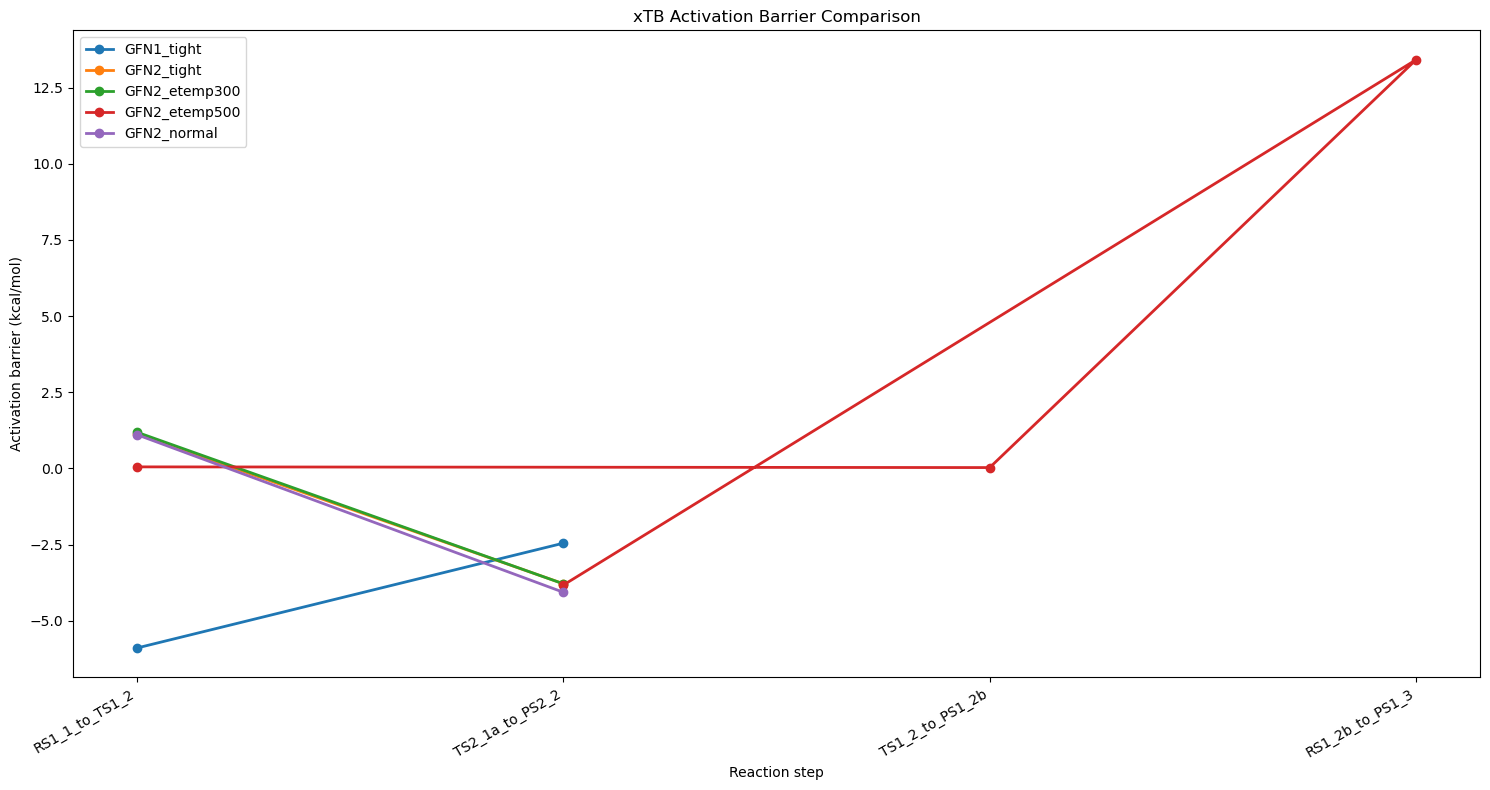

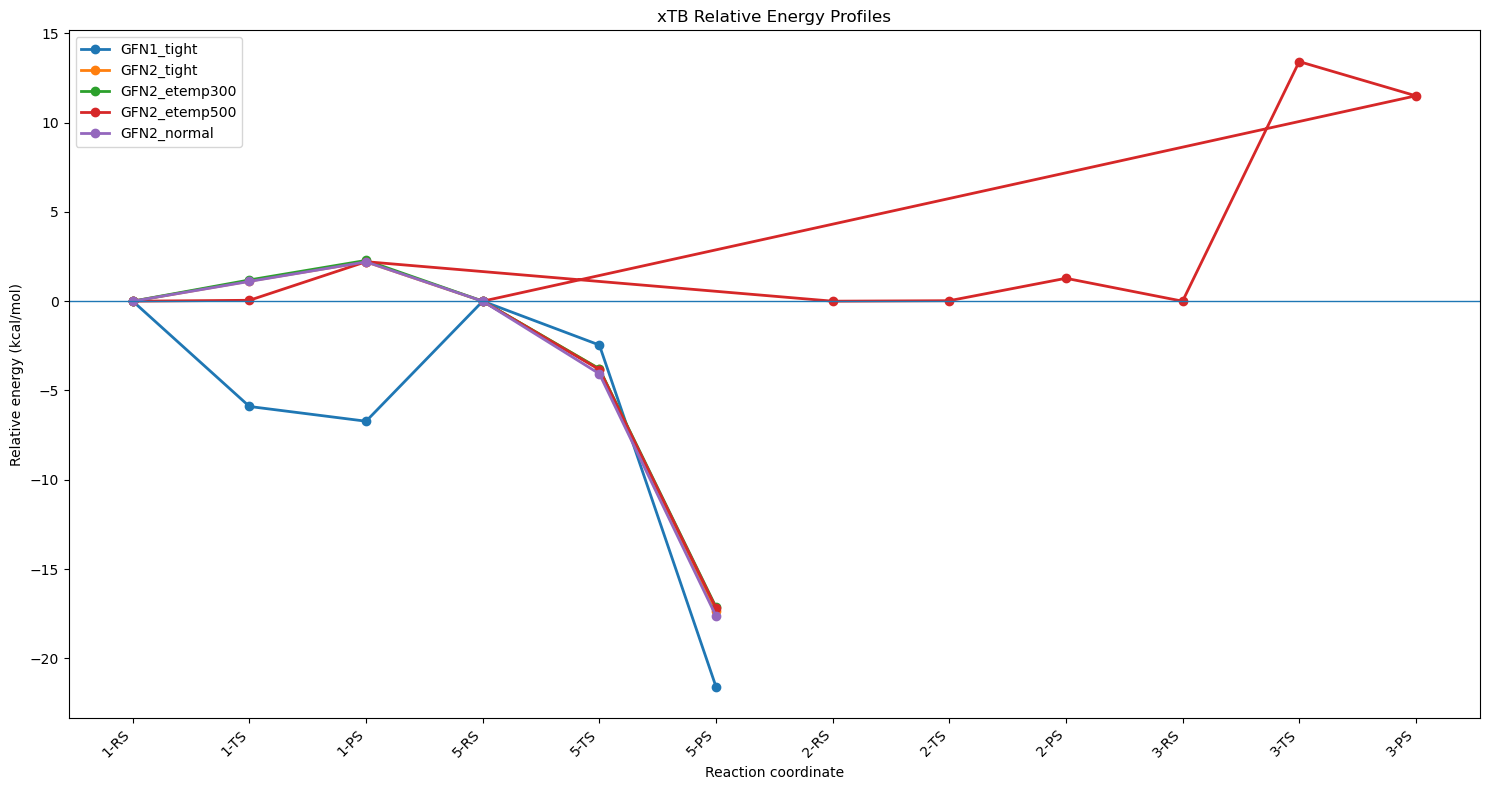



BARRIER SUMMARY ACROSS FIVE xTB PROTOCOLS
           step      mean      std    median       min       max
 RS1_1_to_TS1_2 -0.485050 3.062299  1.107019 -5.897281  1.188620
RS1_2b_to_PS1_3 13.418493      NaN 13.418493 13.418493 13.418493
TS1_2_to_PS1_2b  0.027295      NaN  0.027295  0.027295  0.027295
TS2_1a_to_PS2_2 -3.585818 0.642376 -3.789630 -4.067056 -2.455605


STAGE 3 COMPLETE

Files created:
Energy table:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\stage2_five_xtb_protocols\stage3_energy_table.csv

Activation barriers:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\stage2_five_xtb_protocols\stage3_activation_barriers.csv

Barrier matrix:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\stage2_five_xtb_protocols\stage3_barrier_matrix_kcal_mol.csv

Reaction-energy matrix:
D:\PhD_Thesis\LmrR_EVB\charges\fast_lmrr_5QM\xtb_preparation\stage2_five_xtb_protocols\stage3_reaction_energy_matrix_kcal_mol.csv

TS frequency summary:
D:\PhD_Thesis\

In [23]:
# ============================================================
# STAGE 3 — ANALYZE THE 75 STAGE-2 xTB CALCULATIONS
# ============================================================
#
# Reads the already-completed Stage 2 calculations.
#
# Produces:
#   1. RS / TS / PS energies
#   2. activation barriers
#   3. reaction energies
#   4. barrier comparison matrix
#   5. energy-profile data
#   6. TS imaginary-frequency summary
#   7. CSV files
#   8. plots
#
# NO NEW xTB CALCULATIONS ARE RUN.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. DIRECTORY
# ============================================================

STAGE2_DIR = Path(
    r"D:\PhD_Thesis\LmrR_EVB"
    r"\charges\fast_lmrr_5QM"
    r"\xtb_preparation"
    r"\stage2_five_xtb_protocols"
)


MASTER_FILE = (
    STAGE2_DIR /
    "stage2_75_calculations.csv"
)


if not MASTER_FILE.exists():

    raise FileNotFoundError(
        f"Stage-2 master file not found:\n"
        f"{MASTER_FILE}"
    )


# ============================================================
# 2. LOAD RESULTS
# ============================================================

df = pd.read_csv(
    MASTER_FILE
)


print("=" * 75)
print("STAGE 3 — xTB ENERGY AND BARRIER ANALYSIS")
print("=" * 75)

print(
    f"\nTotal records: {len(df)}"
)


# ============================================================
# 3. DEFINITIONS
# ============================================================

PROTOCOLS = [

    "GFN1_tight",

    "GFN2_tight",

    "GFN2_etemp300",

    "GFN2_etemp500",

    "GFN2_normal",

]


STEPS = [

    "RS1_1_to_TS1_2",

    "TS1_2_to_PS1_2b",

    "RS1_2b_to_PS1_3",

    "RS2_1_to_TS2_1a",

    "TS2_1a_to_PS2_2",

]


ROLES = [
    "RS",
    "TS",
    "PS",
]


# Conversion factors

EH_TO_KCAL = 627.509474

EH_TO_KJ = 2625.49962


# ============================================================
# 4. CHECK COMPLETENESS
# ============================================================

expected = {

    (protocol, step, role)

    for protocol in PROTOCOLS

    for step in STEPS

    for role in ROLES

}


actual = {

    (
        row["protocol"],
        row["step"],
        row["role"]
    )

    for _, row in df.iterrows()

}


missing = expected - actual


if missing:

    print("\n⚠ Missing calculations:")

    for item in sorted(missing):

        print(
            " ",
            item
        )

else:

    print(
        "✓ All 75 calculation records present"
    )


# ============================================================
# 5. SUCCESS CHECK
# ============================================================

successful = df[
    df["status"] == "SUCCESS"
].copy()


print(
    f"✓ Successful calculations: "
    f"{len(successful)}/75"
)


if len(successful) != 75:

    print(
        "\n⚠ WARNING:"
    )

    print(
        "Not all 75 calculations succeeded."
    )

    print(
        "Barrier analysis will only use "
        "complete RS/TS/PS sets."
    )


# ============================================================
# 6. ENERGY TABLE
# ============================================================

energy_table = successful[
    [
        "protocol",
        "step",
        "role",
        "energy_Eh",
        "imaginary_count",
        "n_modes",
        "n_charges",
    ]
].copy()


energy_table_file = (
    STAGE2_DIR /
    "stage3_energy_table.csv"
)


energy_table.to_csv(

    energy_table_file,

    index=False

)


print(
    "\nEnergy table saved:"
)

print(
    energy_table_file
)


# ============================================================
# 7. CALCULATE BARRIERS
# ============================================================

barrier_results = []


for protocol in PROTOCOLS:

    protocol_data = successful[
        successful["protocol"]
        == protocol
    ]


    for step in STEPS:

        step_data = protocol_data[
            protocol_data["step"]
            == step
        ]


        # ----------------------------------------------------
        # Require RS, TS and PS
        # ----------------------------------------------------

        if not all(

            role in
            set(step_data["role"])

            for role in ROLES

        ):

            print(
                f"\n⚠ Incomplete:"
                f" {protocol} | {step}"
            )

            continue


        rs = step_data[
            step_data["role"] == "RS"
        ]["energy_Eh"].iloc[0]


        ts = step_data[
            step_data["role"] == "TS"
        ]["energy_Eh"].iloc[0]


        ps = step_data[
            step_data["role"] == "PS"
        ]["energy_Eh"].iloc[0]


        # ----------------------------------------------------
        # Activation barrier
        # ----------------------------------------------------

        barrier_Eh = (
            ts - rs
        )


        barrier_kcal = (
            barrier_Eh
            *
            EH_TO_KCAL
        )


        barrier_kJ = (
            barrier_Eh
            *
            EH_TO_KJ
        )


        # ----------------------------------------------------
        # Reaction energy
        # ----------------------------------------------------

        reaction_Eh = (
            ps - rs
        )


        reaction_kcal = (
            reaction_Eh
            *
            EH_TO_KCAL
        )


        reaction_kJ = (
            reaction_Eh
            *
            EH_TO_KJ
        )


        # ----------------------------------------------------
        # TS imaginary frequencies
        # ----------------------------------------------------

        ts_row = step_data[
            step_data["role"] == "TS"
        ].iloc[0]


        imaginary_count = (
            ts_row["imaginary_count"]
        )


        imaginary_frequency_text = (
            ts_row[
                "imaginary_frequencies"
            ]
        )


        barrier_results.append({

            "protocol":
                protocol,

            "step":
                step,

            "RS_energy_Eh":
                rs,

            "TS_energy_Eh":
                ts,

            "PS_energy_Eh":
                ps,

            "barrier_Eh":
                barrier_Eh,

            "barrier_kcal_mol":
                barrier_kcal,

            "barrier_kJ_mol":
                barrier_kJ,

            "reaction_energy_Eh":
                reaction_Eh,

            "reaction_energy_kcal_mol":
                reaction_kcal,

            "reaction_energy_kJ_mol":
                reaction_kJ,

            "TS_imaginary_count":
                imaginary_count,

            "TS_imaginary_frequencies_cm-1":
                imaginary_frequency_text,

        })


# ============================================================
# 8. BARRIER DATAFRAME
# ============================================================

barriers_df = pd.DataFrame(
    barrier_results
)


barrier_file = (
    STAGE2_DIR /
    "stage3_activation_barriers.csv"
)


barriers_df.to_csv(

    barrier_file,

    index=False

)


print("\n")
print("=" * 75)
print("ACTIVATION BARRIERS")
print("=" * 75)


print(

    barriers_df[
        [
            "protocol",
            "step",
            "barrier_kcal_mol",
            "barrier_kJ_mol",
            "TS_imaginary_count",
        ]
    ].to_string(
        index=False
    )

)


# ============================================================
# 9. BARRIER MATRIX
# ============================================================

barrier_matrix = barriers_df.pivot(

    index="step",

    columns="protocol",

    values="barrier_kcal_mol"

)


matrix_file = (
    STAGE2_DIR /
    "stage3_barrier_matrix_kcal_mol.csv"
)


barrier_matrix.to_csv(
    matrix_file
)


print("\n")
print("=" * 75)
print("ACTIVATION BARRIER MATRIX — kcal/mol")
print("=" * 75)


print(
    barrier_matrix.to_string()
)


# ============================================================
# 10. REACTION ENERGY MATRIX
# ============================================================

reaction_matrix = barriers_df.pivot(

    index="step",

    columns="protocol",

    values="reaction_energy_kcal_mol"

)


reaction_file = (
    STAGE2_DIR /
    "stage3_reaction_energy_matrix_kcal_mol.csv"
)


reaction_matrix.to_csv(
    reaction_file
)


print("\n")
print("=" * 75)
print("REACTION ENERGY MATRIX — kcal/mol")
print("=" * 75)


print(
    reaction_matrix.to_string()
)


# ============================================================
# 11. TS IMAGINARY FREQUENCY SUMMARY
# ============================================================

ts_summary = barriers_df[
    [
        "protocol",
        "step",
        "TS_imaginary_count",
        "TS_imaginary_frequencies_cm-1",
    ]
].copy()


ts_file = (
    STAGE2_DIR /
    "stage3_TS_frequency_summary.csv"
)


ts_summary.to_csv(

    ts_file,

    index=False

)


print("\n")
print("=" * 75)
print("TS IMAGINARY FREQUENCY SUMMARY")
print("=" * 75)


print(
    ts_summary.to_string(
        index=False
    )
)


# ============================================================
# 12. BARRIER PLOT
# ============================================================

PLOT_DIR = (
    STAGE2_DIR /
    "stage3_plots"
)


PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


plt.figure(
    figsize=(15, 8)
)


for protocol in PROTOCOLS:

    data = barriers_df[
        barriers_df["protocol"]
        == protocol
    ]


    if data.empty:
        continue


    plt.plot(

        data["step"],

        data[
            "barrier_kcal_mol"
        ],

        marker="o",

        linewidth=2,

        label=protocol

    )


plt.ylabel(
    "Activation barrier (kcal/mol)"
)

plt.xlabel(
    "Reaction step"
)

plt.title(
    "xTB Activation Barrier Comparison"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend()

plt.tight_layout()


barrier_plot = (
    PLOT_DIR /
    "xTB_activation_barriers.png"
)


plt.savefig(

    barrier_plot,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# 13. ENERGY PROFILE
# ============================================================

plt.figure(
    figsize=(15, 8)
)


for protocol in PROTOCOLS:

    data = successful[
        successful["protocol"]
        == protocol
    ].copy()


    if data.empty:
        continue


    # --------------------------------------------------------
    # Relative energy within each reaction step
    # --------------------------------------------------------

    profile_x = []
    profile_y = []


    for step_number, step in enumerate(
        STEPS,
        start=1
    ):

        step_data = data[
            data["step"] == step
        ]


        if len(step_data) != 3:
            continue


        rs = step_data[
            step_data["role"] == "RS"
        ]["energy_Eh"].iloc[0]


        for role in [
            "RS",
            "TS",
            "PS"
        ]:

            row = step_data[
                step_data["role"] == role
            ]


            if row.empty:
                continue


            e = row[
                "energy_Eh"
            ].iloc[0]


            profile_x.append(
                f"{step_number}-{role}"
            )


            profile_y.append(

                (
                    e - rs
                )
                *
                EH_TO_KCAL

            )


    if profile_x:

        plt.plot(

            profile_x,

            profile_y,

            marker="o",

            linewidth=2,

            label=protocol

        )


plt.axhline(
    0,
    linewidth=1
)


plt.ylabel(
    "Relative energy (kcal/mol)"
)

plt.xlabel(
    "Reaction coordinate"
)

plt.title(
    "xTB Relative Energy Profiles"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend()

plt.tight_layout()


profile_plot = (
    PLOT_DIR /
    "xTB_relative_energy_profiles.png"
)


plt.savefig(

    profile_plot,

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# ============================================================
# 14. SUMMARY STATISTICS ACROSS PROTOCOLS
# ============================================================

summary_stats = (

    barriers_df

    .groupby("step")

    ["barrier_kcal_mol"]

    .agg(
        [
            "mean",
            "std",
            "median",
            "min",
            "max",
        ]
    )

    .reset_index()

)


summary_file = (
    STAGE2_DIR /
    "stage3_barrier_summary_statistics.csv"
)


summary_stats.to_csv(

    summary_file,

    index=False

)


print("\n")
print("=" * 75)
print("BARRIER SUMMARY ACROSS FIVE xTB PROTOCOLS")
print("=" * 75)


print(
    summary_stats.to_string(
        index=False
    )
)


# ============================================================
# 15. FINAL OUTPUT
# ============================================================

print("\n")
print("=" * 75)
print("STAGE 3 COMPLETE")
print("=" * 75)

print(
    "\nFiles created:"
)

print(
    "Energy table:"
)

print(
    energy_table_file
)

print(
    "\nActivation barriers:"
)

print(
    barrier_file
)

print(
    "\nBarrier matrix:"
)

print(
    matrix_file
)

print(
    "\nReaction-energy matrix:"
)

print(
    reaction_file
)

print(
    "\nTS frequency summary:"
)

print(
    ts_file
)

print(
    "\nBarrier plot:"
)

print(
    barrier_plot
)

print(
    "\nEnergy-profile plot:"
)

print(
    profile_plot
)

print(
    "\nSummary statistics:"
)

print(
    summary_file
)

print("\n")
print("=" * 75)